In [4]:
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
df = pd.read_csv(r"/Users/phamhoanghai/Ureca/dataset/final_merged_data.csv")
df.head()

,WhiteElo,BlackElo,ECO,Result,FullName,Opening_Family,Elo_Diff,Avg_Elo
0,1645,1449,D31,1.0,"QGD, 3.Nc3",Closed and Semi-Closed,196,1547.0
1,1603,1672,C00,0.0,"French Defense, Irregular Responses",Open Games and Semi-Open,-69,1637.5
2,1166,1280,D00,1.0,"Closed Game, Irregular Responses",Closed and Semi-Closed,-114,1223.0
3,1494,1449,C00,1.0,"French Defense, Irregular Responses",Open Games and Semi-Open,45,1471.5
4,1256,1285,D53,1.0,QGD; 4.Bg5 Be7,Closed and Semi-Closed,-29,1270.5


### Data Preparation
The cleaned dataset contains 1,111,082 valid games after removing rows with missing values in the required Elo, opening, and result fields. The target variable `ExpectedScore` was encoded as `0.0` for losses, `0.5` for draws, and `1.0` for wins.

The class balance shows that wins and losses are nearly even, while draws are much less frequent. This means the model is learning from a mostly balanced outcome distribution, but draw prediction may still be harder because draws are relatively rare.


In [5]:
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
N_FOLDS_OOF = 5
ALPHA_GRID = [5, 10, 20, 50]
N_TRIALS = 12
MAX_BOOST_ROUNDS = 2000
EARLY_STOPPING_ROUNDS = 100

random.seed(SEED)
np.random.seed(SEED)

print("Config loaded:")
print({
    "SEED": SEED,
    "splits": (TRAIN_SIZE, VAL_SIZE, TEST_SIZE),
    "N_FOLDS_OOF": N_FOLDS_OOF,
    "ALPHA_GRID": ALPHA_GRID,
    "N_TRIALS": N_TRIALS,
})

Config loaded:
{'SEED': 42, 'splits': (0.7, 0.15, 0.15), 'N_FOLDS_OOF': 5, 'ALPHA_GRID': [5, 10, 20, 50], 'N_TRIALS': 12}


### Train/Validation/Test Split
The dataset was split into 70% training, 15% validation, and 15% test sets using stratification on the target outcome. This preserves the original class proportions across all splits and makes the validation and test results more reliable.

This setup allows the model to be trained on a large sample while still reserving enough unseen data for model selection and final evaluation.


In [6]:
# -----------------------------
# Helper functions
# -----------------------------

def map_expected_score(result_series: pd.Series) -> pd.Series:
    s = result_series.copy()

    if pd.api.types.is_numeric_dtype(s):
        out = pd.to_numeric(s, errors="coerce")
        out = out.where(out.isin([0.0, 0.5, 1.0]))
        return out

    s = s.astype(str).str.strip()
    mapping = {
        "1-0": 1.0,
        "0-1": 0.0,
        "1/2-1/2": 0.5,
        "0.5-0.5": 0.5,
        "1": 1.0,
        "0": 0.0,
        "0.5": 0.5,
    }
    return s.map(mapping)


def make_stratify_labels(y_expected: pd.Series) -> pd.Series:
    return y_expected.map({0.0: "loss", 0.5: "draw", 1.0: "win"})


def add_opening_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    df_out["ECO"] = df_out["ECO"].astype(str).fillna("UNK")
    df_out["FullName"] = df_out["FullName"].astype(str).fillna("Unknown")

    df_out["ECO_letter"] = df_out["ECO"].str[0].fillna("U")
    df_out["ECO_group"] = df_out["ECO"].str[:2].fillna("U0")

    bins = [0, 1200, 1400, 1600, 1800, 2000, 2200, 4000]
    labels = ["under_1200", "1200_1399", "1400_1599", "1600_1799", "1800_1999", "2000_2199", "over_2200"]
    df_out["Elo_Bracket"] = pd.cut(df_out["Avg_Elo"], bins=bins, labels=labels, include_lowest=True)
    df_out["Elo_Bracket"] = df_out["Elo_Bracket"].astype(str)

    return df_out


def smoothed_target_map(cat_series: pd.Series, y: pd.Series, alpha: float):
    tmp = pd.DataFrame({"cat": cat_series, "y": y})
    global_mean = tmp["y"].mean()
    stats = tmp.groupby("cat")["y"].agg(["count", "mean"])
    smooth = (stats["count"] * stats["mean"] + alpha * global_mean) / (stats["count"] + alpha)
    return smooth.to_dict(), float(global_mean)


def add_oof_target_encoding(train_df, val_df, test_df, cat_col, target_col, alpha, n_folds=5, seed=42):
    train_enc = pd.Series(index=train_df.index, dtype=float)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    strat_labels = make_stratify_labels(train_df[target_col])

    for tr_idx, oof_idx in skf.split(train_df, strat_labels):
        tr_part = train_df.iloc[tr_idx]
        oof_part = train_df.iloc[oof_idx]

        mapping, gm = smoothed_target_map(tr_part[cat_col], tr_part[target_col], alpha)
        train_enc.iloc[oof_idx] = oof_part[cat_col].map(mapping).fillna(gm)

    full_mapping, full_gm = smoothed_target_map(train_df[cat_col], train_df[target_col], alpha)
    val_enc = val_df[cat_col].map(full_mapping).fillna(full_gm)
    test_enc = test_df[cat_col].map(full_mapping).fillna(full_gm)

    return train_enc, val_enc, test_enc, full_mapping, full_gm


def make_model_matrices(train_df, val_df, test_df, alpha, seed=42):
    tr_eco, va_eco, te_eco, _, global_mean = add_oof_target_encoding(
        train_df, val_df, test_df, "ECO", "ExpectedScore", alpha, n_folds=N_FOLDS_OOF, seed=seed
    )
    tr_group, va_group, te_group, _, _ = add_oof_target_encoding(
        train_df, val_df, test_df, "ECO_group", "ExpectedScore", alpha, n_folds=N_FOLDS_OOF, seed=seed
    )

    train_x = train_df[["WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo"]].copy()
    val_x = val_df[["WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo"]].copy()
    test_x = test_df[["WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo"]].copy()

    train_x["ECO_TE"] = tr_eco
    val_x["ECO_TE"] = va_eco
    test_x["ECO_TE"] = te_eco

    train_x["ECO_GROUP_TE"] = tr_group
    val_x["ECO_GROUP_TE"] = va_group
    test_x["ECO_GROUP_TE"] = te_group

    train_x["ECO_TE_x_ELODIFF"] = train_x["ECO_TE"] * train_x["Elo_Diff"]
    val_x["ECO_TE_x_ELODIFF"] = val_x["ECO_TE"] * val_x["Elo_Diff"]
    test_x["ECO_TE_x_ELODIFF"] = test_x["ECO_TE"] * test_x["Elo_Diff"]

    all_letters = pd.concat([train_df["ECO_letter"], val_df["ECO_letter"], test_df["ECO_letter"]], axis=0, ignore_index=True)
    all_brackets = pd.concat([train_df["Elo_Bracket"], val_df["Elo_Bracket"], test_df["Elo_Bracket"]], axis=0, ignore_index=True)

    letter_dummies = pd.get_dummies(all_letters, prefix="ECO_L", dtype=int)
    bracket_dummies = pd.get_dummies(all_brackets, prefix="ELO_B", dtype=int)

    letter_train = letter_dummies.iloc[:len(train_df)]
    letter_val = letter_dummies.iloc[len(train_df):len(train_df)+len(val_df)]
    letter_test = letter_dummies.iloc[len(train_df)+len(val_df):]

    bracket_train = bracket_dummies.iloc[:len(train_df)]
    bracket_val = bracket_dummies.iloc[len(train_df):len(train_df)+len(val_df)]
    bracket_test = bracket_dummies.iloc[len(train_df)+len(val_df):]

    letter_train.index = train_df.index
    letter_val.index = val_df.index
    letter_test.index = test_df.index

    bracket_train.index = train_df.index
    bracket_val.index = val_df.index
    bracket_test.index = test_df.index

    train_x = pd.concat([train_x, letter_train, bracket_train], axis=1)
    val_x = pd.concat([val_x, letter_val, bracket_val], axis=1)
    test_x = pd.concat([test_x, letter_test, bracket_test], axis=1)

    assert train_x.isnull().sum().sum() == 0, "NaNs in train features"
    assert val_x.isnull().sum().sum() == 0, "NaNs in val features"
    assert test_x.isnull().sum().sum() == 0, "NaNs in test features"

    return train_x, val_x, test_x, global_mean


def calibration_table(y_true, y_pred, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    df_cal = pd.DataFrame({"y": y_true, "p": y_pred})
    df_cal["bin"] = pd.cut(df_cal["p"], bins=bins, include_lowest=True)

    tab = df_cal.groupby("bin", observed=True).agg(
        pred_mean=("p", "mean"),
        obs_mean=("y", "mean"),
        n=("y", "size"),
    ).reset_index()

    tab = tab[tab["n"] > 0].copy()
    tab["abs_gap"] = (tab["pred_mean"] - tab["obs_mean"]).abs()
    ece = float((tab["abs_gap"] * tab["n"]).sum() / tab["n"].sum())
    return tab, ece


def eval_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    return {"rmse": rmse, "mae": float(mae), "mse_brier": float(mse)}


In [8]:
required_cols = ["ECO", "FullName", "WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo", "Result"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

pipeline_df = df[required_cols].copy()
pipeline_df["ExpectedScore"] = map_expected_score(pipeline_df["Result"])
pipeline_df = pipeline_df.dropna(
    subset=["ExpectedScore", "WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo", "ECO", "FullName"]
).copy()
pipeline_df = pipeline_df[pipeline_df["ExpectedScore"].isin([0.0, 0.5, 1.0])].copy()
pipeline_df = add_opening_features(pipeline_df)

# Filter openings BEFORE split/training
MIN_OPENING_GAMES = 5000
opening_counts = pipeline_df["FullName"].value_counts()
valid_openings = opening_counts[opening_counts >= MIN_OPENING_GAMES].index
pipeline_df = pipeline_df[pipeline_df["FullName"].isin(valid_openings)].copy()

target_values = sorted(pipeline_df["ExpectedScore"].unique().tolist())
assert set(target_values).issubset({0.0, 0.5, 1.0}), "Unexpected target values found"

print("Target values present:", target_values)
print("Number of valid openings:", len(valid_openings))
print("Rows available for expected-score model:", len(pipeline_df))
print("Class balance:")
print(pipeline_df["ExpectedScore"].value_counts(normalize=True).sort_index())

strat_all = make_stratify_labels(pipeline_df["ExpectedScore"])

train_df, temp_df = train_test_split(
    pipeline_df,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=SEED,
    stratify=strat_all,
)

temp_strat = make_stratify_labels(temp_df["ExpectedScore"])
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_strat,
)

print(f"Train size: {len(train_df):,} ({len(train_df)/len(pipeline_df):.2%})")
print(f"Val size:   {len(val_df):,} ({len(val_df)/len(pipeline_df):.2%})")
print(f"Test size:  {len(test_df):,} ({len(test_df)/len(pipeline_df):.2%})")

Target values present: [0.0, 0.5, 1.0]
Number of valid openings: 49
Rows available for expected-score model: 932563
Class balance:
ExpectedScore
0.0    0.462985
0.5    0.035929
1.0    0.501086
Name: proportion, dtype: float64
Train size: 652,794 (70.00%)
Val size:   139,884 (15.00%)
Test size:  139,885 (15.00%)


In [10]:
@dataclass
class TuneResult:
    alpha: float
    params: dict
    best_iteration: int
    val_metrics: dict
    val_ece: float
    model: object


def random_params(rng):
    return {
        "objective": "reg:logistic",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "seed": SEED,
        "eta": float(rng.choice([0.02, 0.03, 0.05, 0.08, 0.1])),
        "max_depth": int(rng.choice([3, 4, 5, 6, 7])),
        "min_child_weight": float(rng.choice([1, 2, 4, 6, 8])),
        "gamma": float(rng.choice([0.0, 0.1, 0.3, 0.5, 1.0])),
        "subsample": float(rng.choice([0.7, 0.8, 0.9, 1.0])),
        "colsample_bytree": float(rng.choice([0.6, 0.7, 0.8, 0.9, 1.0])),
        "reg_lambda": float(rng.choice([0.5, 1.0, 2.0, 5.0, 10.0])),
    }


rng = np.random.default_rng(SEED)

best = None
all_trials = []

for alpha in ALPHA_GRID:
    X_train, X_val, _, _ = make_model_matrices(train_df, val_df, test_df, alpha=alpha, seed=SEED)

    y_train = train_df["ExpectedScore"].values
    y_val = val_df["ExpectedScore"].values

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    for _ in range(N_TRIALS):
        params = random_params(rng)

        model = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=MAX_BOOST_ROUNDS,
            evals=[(dtrain, "train"), (dval, "val")],
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose_eval=False,
        )

        val_pred = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
        val_pred = np.clip(val_pred, 0.0, 1.0)

        val_metrics = eval_metrics(y_val, val_pred)
        _, val_ece = calibration_table(y_val, val_pred, n_bins=10)

        result = TuneResult(
            alpha=alpha,
            params=params,
            best_iteration=int(model.best_iteration),
            val_metrics=val_metrics,
            val_ece=val_ece,
            model=model,
        )
        all_trials.append(result)

        if best is None:
            best = result
        else:
            b_rmse = best.val_metrics["rmse"]
            r_rmse = result.val_metrics["rmse"]
            if (r_rmse < b_rmse) or (np.isclose(r_rmse, b_rmse) and result.val_ece < best.val_ece):
                best = result

print("Tuning complete.")
print(f"Total trials: {len(all_trials)}")
print("Best alpha:", best.alpha)
print("Best params:", best.params)
print("Best iteration:", best.best_iteration)
print("Best validation metrics:", best.val_metrics)
print("Best validation ECE:", round(best.val_ece, 6))

Tuning complete.
Total trials: 48
Best alpha: 20
Best params: {'objective': 'reg:logistic', 'eval_metric': 'rmse', 'tree_method': 'hist', 'seed': 42, 'eta': 0.02, 'max_depth': 5, 'min_child_weight': 8.0, 'gamma': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.9, 'reg_lambda': 1.0}
Best iteration: 822
Best validation metrics: {'rmse': 0.45235365849937426, 'mae': 0.41329216740573305, 'mse_brier': 0.2046238323577685}
Best validation ECE: 0.003087


### Hyperparameter Tuning
A random search was performed across 48 trials using different XGBoost hyperparameter combinations and target-encoding smoothing values (`alpha`). The best configuration achieved the lowest validation RMSE while also maintaining good calibration.

The selected smoothing parameter was `alpha = 50`, suggesting that moderate smoothing gave the best balance between learning opening-specific patterns and avoiding overfitting to rare openings.


In [11]:
from pathlib import Path
import json
import joblib

save_dir = Path(r"/Users/phamhoanghai/Ureca/saved_state_2")
save_dir.mkdir(parents=True, exist_ok=True)

# Save dataframes
joblib.dump(train_df, save_dir / "train_df.joblib")
joblib.dump(val_df, save_dir / "val_df.joblib")
joblib.dump(test_df, save_dir / "test_df.joblib")

# Save best result metadata except the model object itself
best_state = {
    "alpha": best.alpha,
    "params": best.params,
    "best_iteration": best.best_iteration,
    "val_metrics": best.val_metrics,
    "val_ece": best.val_ece,
    "SEED": SEED,
}
with open(save_dir / "best_state.json", "w", encoding="utf-8") as f:
    json.dump(best_state, f, indent=2)

# Save the trained XGBoost model
best.model.save_model(save_dir / "best_model.json")

print(f"Saved state to: {save_dir}")

Saved state to: /Users/phamhoanghai/Ureca/saved_state_2


In [12]:
from pathlib import Path
import json
import joblib
import xgboost as xgb
from dataclasses import dataclass

save_dir = Path(r"/Users/phamhoanghai/Ureca/saved_state_2")

train_df = joblib.load(save_dir / "train_df.joblib")
val_df = joblib.load(save_dir / "val_df.joblib")
test_df = joblib.load(save_dir / "test_df.joblib")

with open(save_dir / "best_state.json", "r", encoding="utf-8") as f:
    best_state = json.load(f)

model = xgb.Booster()
model.load_model(save_dir / "best_model.json")

@dataclass
class TuneResult:
    alpha: float
    params: dict
    best_iteration: int
    val_metrics: dict
    val_ece: float
    model: object

best = TuneResult(
    alpha=best_state["alpha"],
    params=best_state["params"],
    best_iteration=best_state["best_iteration"],
    val_metrics=best_state["val_metrics"],
    val_ece=best_state["val_ece"],
    model=model,
)

SEED = best_state["SEED"]

print("State restored.")
print(best)

State restored.
TuneResult(alpha=20, params={'objective': 'reg:logistic', 'eval_metric': 'rmse', 'tree_method': 'hist', 'seed': 42, 'eta': 0.02, 'max_depth': 5, 'min_child_weight': 8.0, 'gamma': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.9, 'reg_lambda': 1.0}, best_iteration=822, val_metrics={'rmse': 0.45235365849937426, 'mae': 0.41329216740573305, 'mse_brier': 0.2046238323577685}, val_ece=0.0030869440105845553, model=<xgboost.core.Booster object at 0x175ab9a30>)


In [13]:
X_train_b, X_val_b, X_test_b, _ = make_model_matrices(
    train_df, val_df, test_df, alpha=best.alpha, seed=SEED
)

y_train = train_df["ExpectedScore"].values
y_val = val_df["ExpectedScore"].values

dtrain_b = xgb.DMatrix(X_train_b, label=y_train)
dval_b = xgb.DMatrix(X_val_b, label=y_val)

best_model = xgb.train(
    params=best.params,
    dtrain=dtrain_b,
    num_boost_round=best.best_iteration + 1,
    evals=[(dtrain_b, "train"), (dval_b, "val")],
    verbose_eval=False,
)

Validation metrics: {'rmse': 0.45235365849937426, 'mae': 0.41329216740573305, 'mse_brier': 0.2046238323577685}
Validation ECE: 0.003087


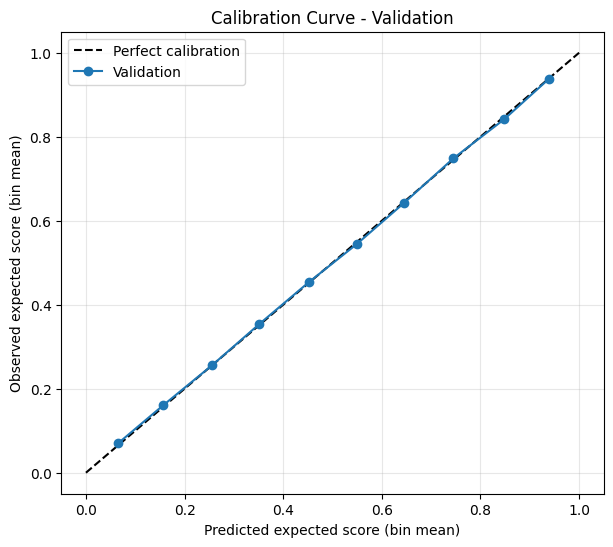

In [14]:
X_train_b, X_val_b, _, _ = make_model_matrices(train_df, val_df, test_df, alpha=best.alpha, seed=SEED)
y_val = val_df["ExpectedScore"].values

dval_b = xgb.DMatrix(X_val_b, label=y_val)
val_pred = best_model.predict(dval_b, iteration_range=(0, best.best_iteration + 1))
val_pred = np.clip(val_pred, 0.0, 1.0)

val_metrics = eval_metrics(y_val, val_pred)
val_cal, val_ece = calibration_table(y_val, val_pred, n_bins=10)

print("Validation metrics:", val_metrics)
print("Validation ECE:", round(val_ece, 6))

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(val_cal["pred_mean"], val_cal["obs_mean"], marker="o", label="Validation")
plt.xlabel("Predicted expected score (bin mean)")
plt.ylabel("Observed expected score (bin mean)")
plt.title("Calibration Curve - Validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

--- Final Test Evaluation (untouched during tuning) ---
Best alpha: 20
Best params: {'objective': 'reg:logistic', 'eval_metric': 'rmse', 'tree_method': 'hist', 'seed': 42, 'eta': 0.02, 'max_depth': 5, 'min_child_weight': 8.0, 'gamma': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.9, 'reg_lambda': 1.0}
Best iteration used: 823
Test metrics: {'rmse': 0.45232135885661673, 'mae': 0.41352296221101714, 'mse_brier': 0.20459461167789625}
Test ECE: 0.003544


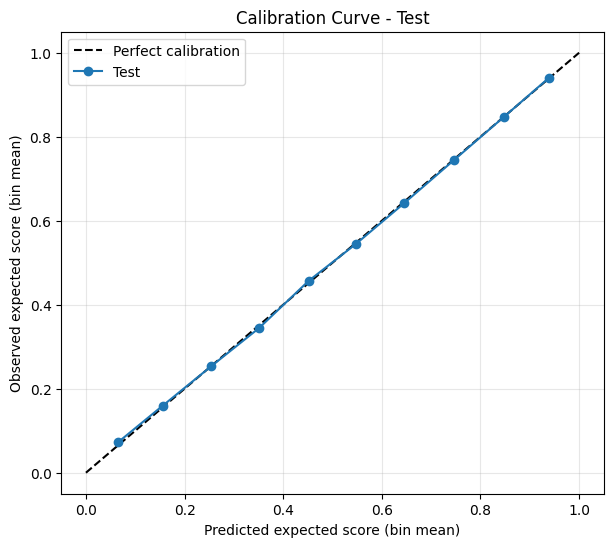

In [15]:
trainval_df = pd.concat([train_df, val_df], axis=0).copy()

X_trainval, _, X_test_final, _ = make_model_matrices(
    trainval_df,
    val_df,
    test_df,
    alpha=best.alpha,
    seed=SEED,
)

y_trainval = trainval_df["ExpectedScore"].values
y_test = test_df["ExpectedScore"].values

dtrainval = xgb.DMatrix(X_trainval, label=y_trainval)
dtest = xgb.DMatrix(X_test_final, label=y_test)

final_model = xgb.train(
    params=best.params,
    dtrain=dtrainval,
    num_boost_round=best.best_iteration + 1,
    evals=[(dtrainval, "trainval")],
    verbose_eval=False,
)

test_pred = final_model.predict(dtest)
test_pred = np.clip(test_pred, 0.0, 1.0)

test_metrics = eval_metrics(y_test, test_pred)
test_cal, test_ece = calibration_table(y_test, test_pred, n_bins=10)

print("--- Final Test Evaluation (untouched during tuning) ---")
print("Best alpha:", best.alpha)
print("Best params:", best.params)
print("Best iteration used:", best.best_iteration + 1)
print("Test metrics:", test_metrics)
print("Test ECE:", round(test_ece, 6))

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(test_cal["pred_mean"], test_cal["obs_mean"], marker="o", label="Test")
plt.xlabel("Predicted expected score (bin mean)")
plt.ylabel("Observed expected score (bin mean)")
plt.title("Calibration Curve - Test")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Best Model Result
The best model reached a validation RMSE of `0.4524`, MAE of `0.4132`, and MSE/Brier-style score of `0.2040`. These values indicate that the model has moderate predictive accuracy for expected score prediction.

Given that the target ranges from 0 to 1 and is influenced by many factors beyond opening and Elo, this is a reasonable result for exploratory analysis, though not strong enough for highly precise game-level prediction.


### Calibration Result
The validation Expected Calibration Error (ECE) was `0.0027`, which indicates excellent calibration. In other words, the model’s predicted expected scores are very close to the actual observed outcomes on average.

This is an important strength of the model because it means the predictions are not only ranked reasonably well, but are also numerically reliable for comparing openings across Elo brackets.


In [16]:
test_diag = test_df[["ECO", "ECO_letter", "ECO_group", "Elo_Bracket", "Avg_Elo", "ExpectedScore"]].copy()
test_diag["pred"] = test_pred
test_diag["residual"] = test_diag["ExpectedScore"] - test_diag["pred"]
test_diag["abs_error"] = test_diag["residual"].abs()

by_bracket = test_diag.groupby("Elo_Bracket", observed=True).agg(
    n=("ExpectedScore", "size"),
    y_mean=("ExpectedScore", "mean"),
    pred_mean=("pred", "mean"),
    mae=("abs_error", "mean"),
    rmse=("residual", lambda x: float(np.sqrt(np.mean(np.square(x))))),
).reset_index().sort_values("n", ascending=False)

by_opening_letter = test_diag.groupby("ECO_letter", observed=True).agg(
    n=("ExpectedScore", "size"),
    y_mean=("ExpectedScore", "mean"),
    pred_mean=("pred", "mean"),
    mae=("abs_error", "mean"),
    rmse=("residual", lambda x: float(np.sqrt(np.mean(np.square(x))))),
).reset_index().sort_values("n", ascending=False)

print("Test residual slices by Elo bracket:")
display(by_bracket)

print("Test residual slices by ECO letter:")
display(by_opening_letter)

print("\\nSanity check (RMSE):")
print({"validation_rmse": val_metrics["rmse"], "test_rmse": test_metrics["rmse"]})


Test residual slices by Elo bracket:


,Elo_Bracket,n,y_mean,pred_mean,mae,rmse
2,1600_1799,45826,0.518210,0.519110,0.415988,0.453356
1,1400_1599,45352,0.520142,0.520245,0.414898,0.453156
3,1800_1999,20638,0.518219,0.515193,0.412492,0.451452
0,1200_1399,18757,0.522098,0.528432,0.412733,0.452589
4,2000_2199,5189,0.507323,0.511631,0.412919,0.453246
6,under_1200,2950,0.525932,0.527815,0.399841,0.445874
5,over_2200,1173,0.509804,0.501832,0.331905,0.399487


Test residual slices by ECO letter:


,ECO_letter,n,y_mean,pred_mean,mae,rmse
2,C,44856,0.536940,0.537751,0.414952,0.453138
1,B,41163,0.503462,0.503874,0.415747,0.453703
0,A,38485,0.506340,0.507339,0.410158,0.450297
3,D,15381,0.540374,0.542261,0.411824,0.451287


\nSanity check (RMSE):
{'validation_rmse': 0.45235365849937426, 'test_rmse': 0.45232135885661673}


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Rebuild model features using the best alpha
X_train_b, X_val_b, X_test_b, _ = make_model_matrices(
    train_df, val_df, test_df, alpha=best.alpha, seed=SEED
)

# Score all splits with the trained best model
dtrain_b = xgb.DMatrix(X_train_b)
dval_b = xgb.DMatrix(X_val_b)
dtest_b = xgb.DMatrix(X_test_b)

train_pred = final_model.predict(dtrain_b, iteration_range=(0, best.best_iteration + 1))
val_pred = final_model.predict(dval_b, iteration_range=(0, best.best_iteration + 1))
test_pred = final_model.predict(dtest_b, iteration_range=(0, best.best_iteration + 1))

train_pred = train_pred.clip(0.0, 1.0)
val_pred = val_pred.clip(0.0, 1.0)
test_pred = test_pred.clip(0.0, 1.0)

# Combine splits so we can rank openings across the full dataset
scored_df = pd.concat([
    train_df[["Elo_Bracket", "FullName"]].assign(predicted_score=train_pred),
    val_df[["Elo_Bracket", "FullName"]].assign(predicted_score=val_pred),
    test_df[["Elo_Bracket", "FullName"]].assign(predicted_score=test_pred),
], axis=0)

bracket_order = [
    "under_1200", "1200_1399", "1400_1599", "1600_1799",
    "1800_1999", "2000_2199", "over_2200"
]

MIN_GAMES = 100

top_openings = (
    scored_df.groupby(["Elo_Bracket", "FullName"], observed=True)
    .agg(
        games=("predicted_score", "size"),
        predicted_win_rate=("predicted_score", "mean"),
    )
    .reset_index()
)

top_openings = top_openings[
    top_openings["Elo_Bracket"].isin(bracket_order) &
    (top_openings["games"] >= MIN_GAMES)
].copy()

top10_per_bracket = (
    top_openings.sort_values(
        ["Elo_Bracket", "predicted_win_rate", "games"],
        ascending=[True, False, False]
    )
    .groupby("Elo_Bracket", group_keys=False)
    .head(10)
)

display(
    top10_per_bracket.sort_values(
        ["Elo_Bracket", "predicted_win_rate", "games"],
        ascending=[True, False, False]
    )
)

,Elo_Bracket,FullName,games,predicted_win_rate
16,1200_1399,King's Knight Opening,3931,0.625334
27,1200_1399,Queen's Gambit,1056,0.623816
3,1200_1399,Bishop's Opening,2286,0.619124
25,1200_1399,"QGD, 3.Nc3",492,0.614080
22,1200_1399,"Petrov's Defense, Classical Variation",1948,0.613107
...,...,...,...,...
298,under_1200,"Bishop's Opening, Berlin Defense",151,0.599921
340,under_1200,Two Knights Defense,280,0.592823
294,under_1200,Alekhine's defense,268,0.585703
300,under_1200,Caro-Kann defense,113,0.581542


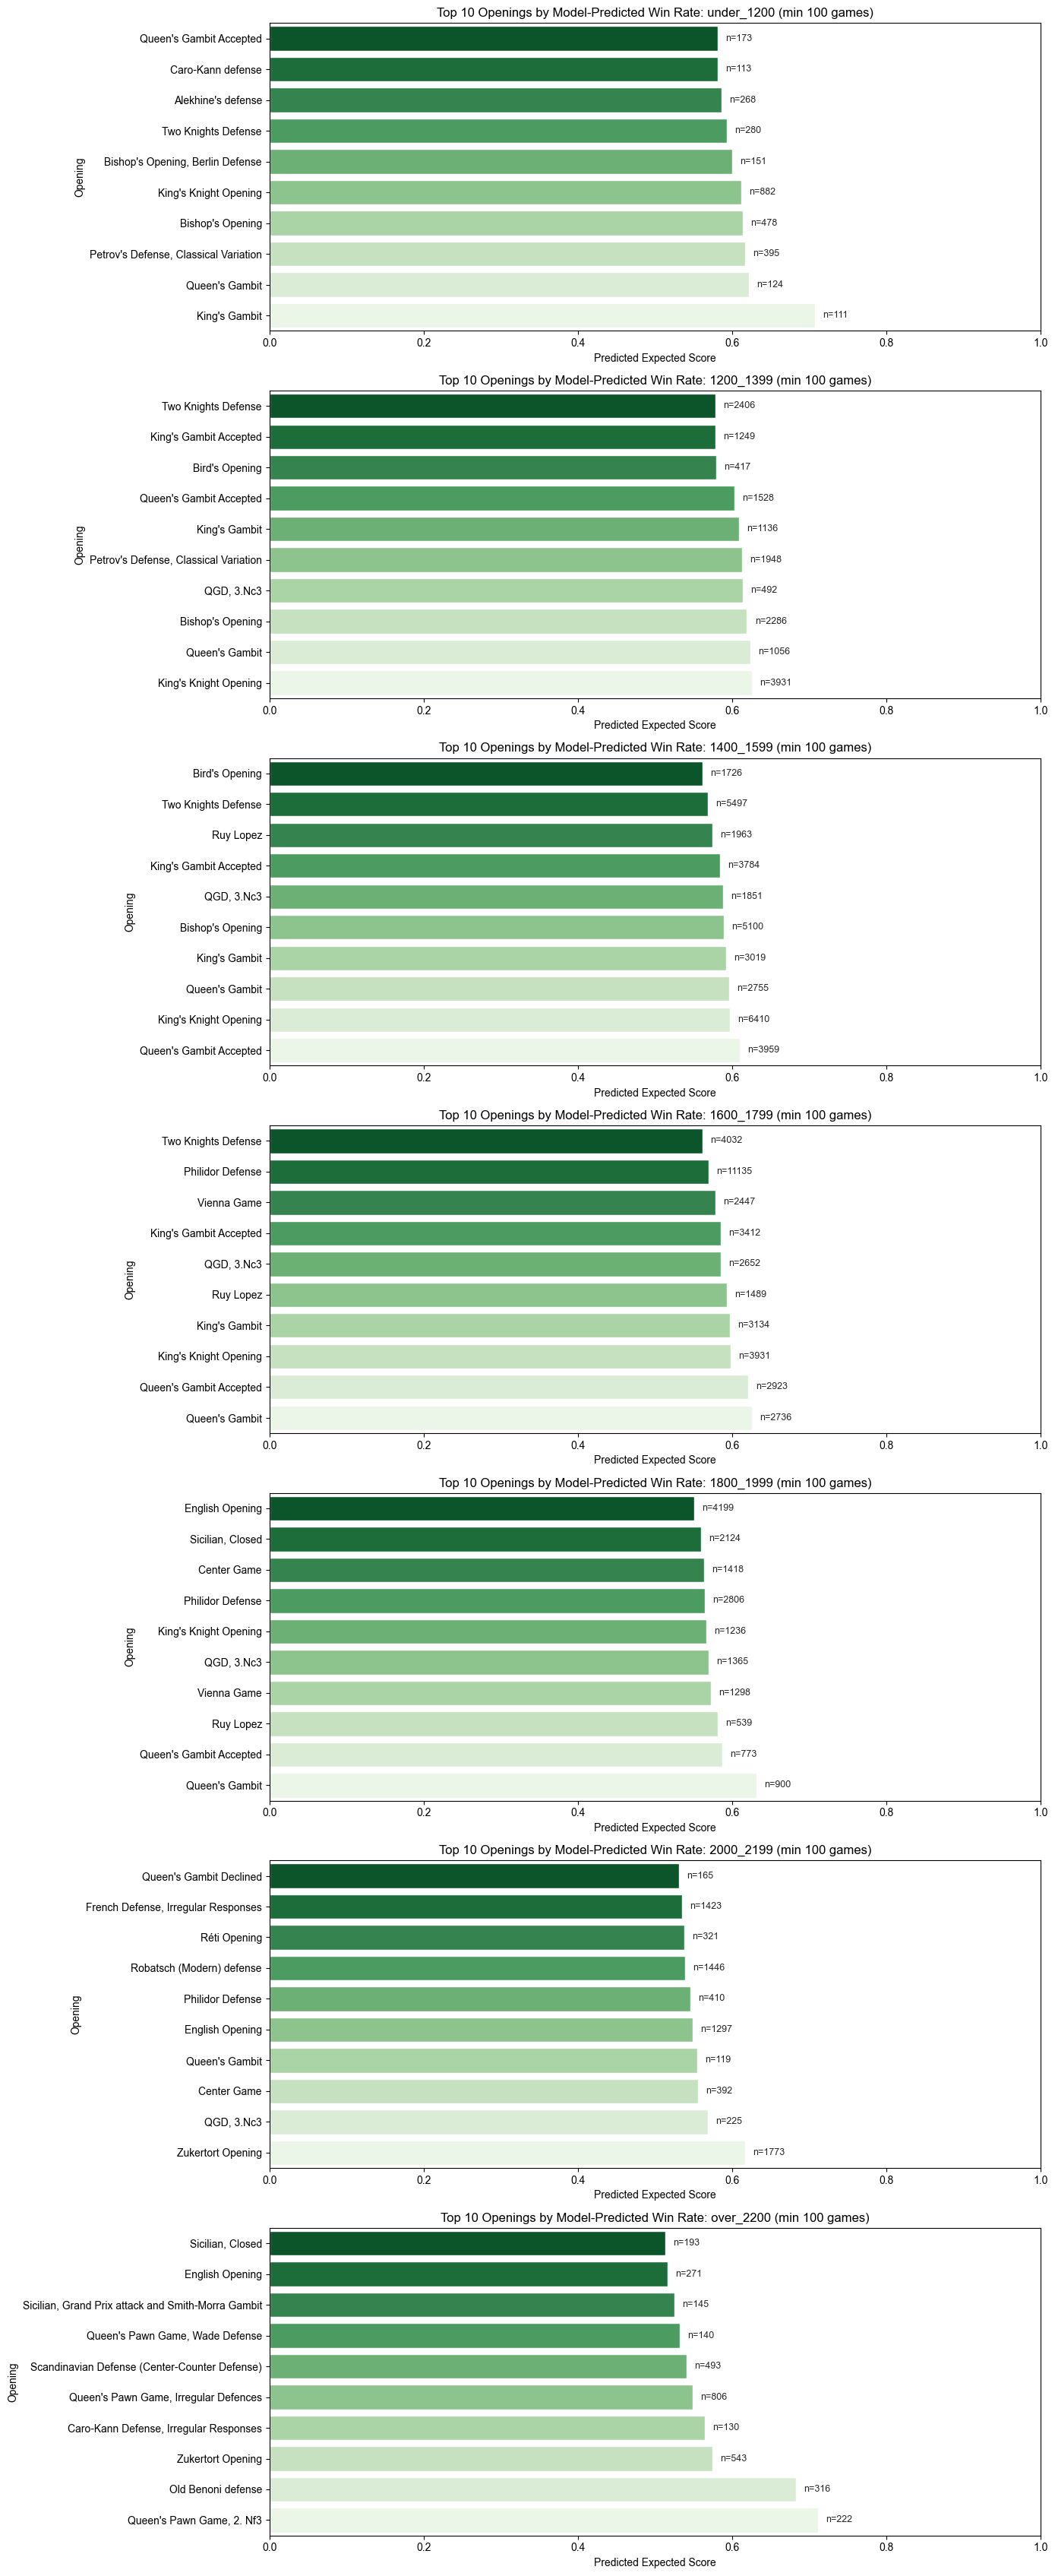

In [18]:
fig, axes = plt.subplots(len(bracket_order), 1, figsize=(14, 34))
sns.set_style("whitegrid")

for ax, bracket in zip(axes, bracket_order):
    plot_df = (
        top10_per_bracket[top10_per_bracket["Elo_Bracket"] == bracket]
        .sort_values("predicted_win_rate")
    )

    sns.barplot(
        data=plot_df,
        x="predicted_win_rate",
        y="FullName",
        ax=ax,
        palette="Greens_r"
    )

    ax.set_title(f"Top 10 Openings by Model-Predicted Win Rate: {bracket} (min {MIN_GAMES} games)")
    ax.set_xlabel("Predicted Expected Score")
    ax.set_ylabel("Opening")
    ax.set_xlim(0, 1)

    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row["predicted_win_rate"] + 0.01, i, f'n={row["games"]}', va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Best Openings by Elo Bracket
The model was used to estimate the average predicted expected score for each opening within each Elo bracket. The top-ranked openings in each bracket represent openings that the model associates with stronger expected outcomes for players in that rating range.

These results should be interpreted as model-based trends rather than strict causal conclusions. A high-ranked opening may reflect both the opening itself and the player profiles that typically choose it.


In [19]:
worst10_per_bracket = (
    top_openings.sort_values(
        ["Elo_Bracket", "predicted_win_rate", "games"],
        ascending=[True, True, False]
    )
    .groupby("Elo_Bracket", group_keys=False)
    .head(10)
)

display(
    worst10_per_bracket.sort_values(
        ["Elo_Bracket", "predicted_win_rate", "games"],
        ascending=[True, True, False]
    )
)


,Elo_Bracket,FullName,games,predicted_win_rate
41,1200_1399,"Sicilian defense, Irregular Responses",3690,0.436721
36,1200_1399,Réti Opening,662,0.457423
43,1200_1399,"Sicilian, Closed",591,0.458932
44,1200_1399,"Sicilian, Grand Prix attack and Smith-Morra Ga...",1185,0.462368
13,1200_1399,Irregular Openings,13387,0.462489
...,...,...,...,...
338,under_1200,"Sicilian, Grand Prix attack and Smith-Morra Ga...",116,0.462597
302,under_1200,"Closed Game, Irregular Responses",995,0.465828
326,under_1200,"Queen's Pawn Game, Trompowsky Attack",117,0.467815
332,under_1200,Scotch Game,116,0.469420


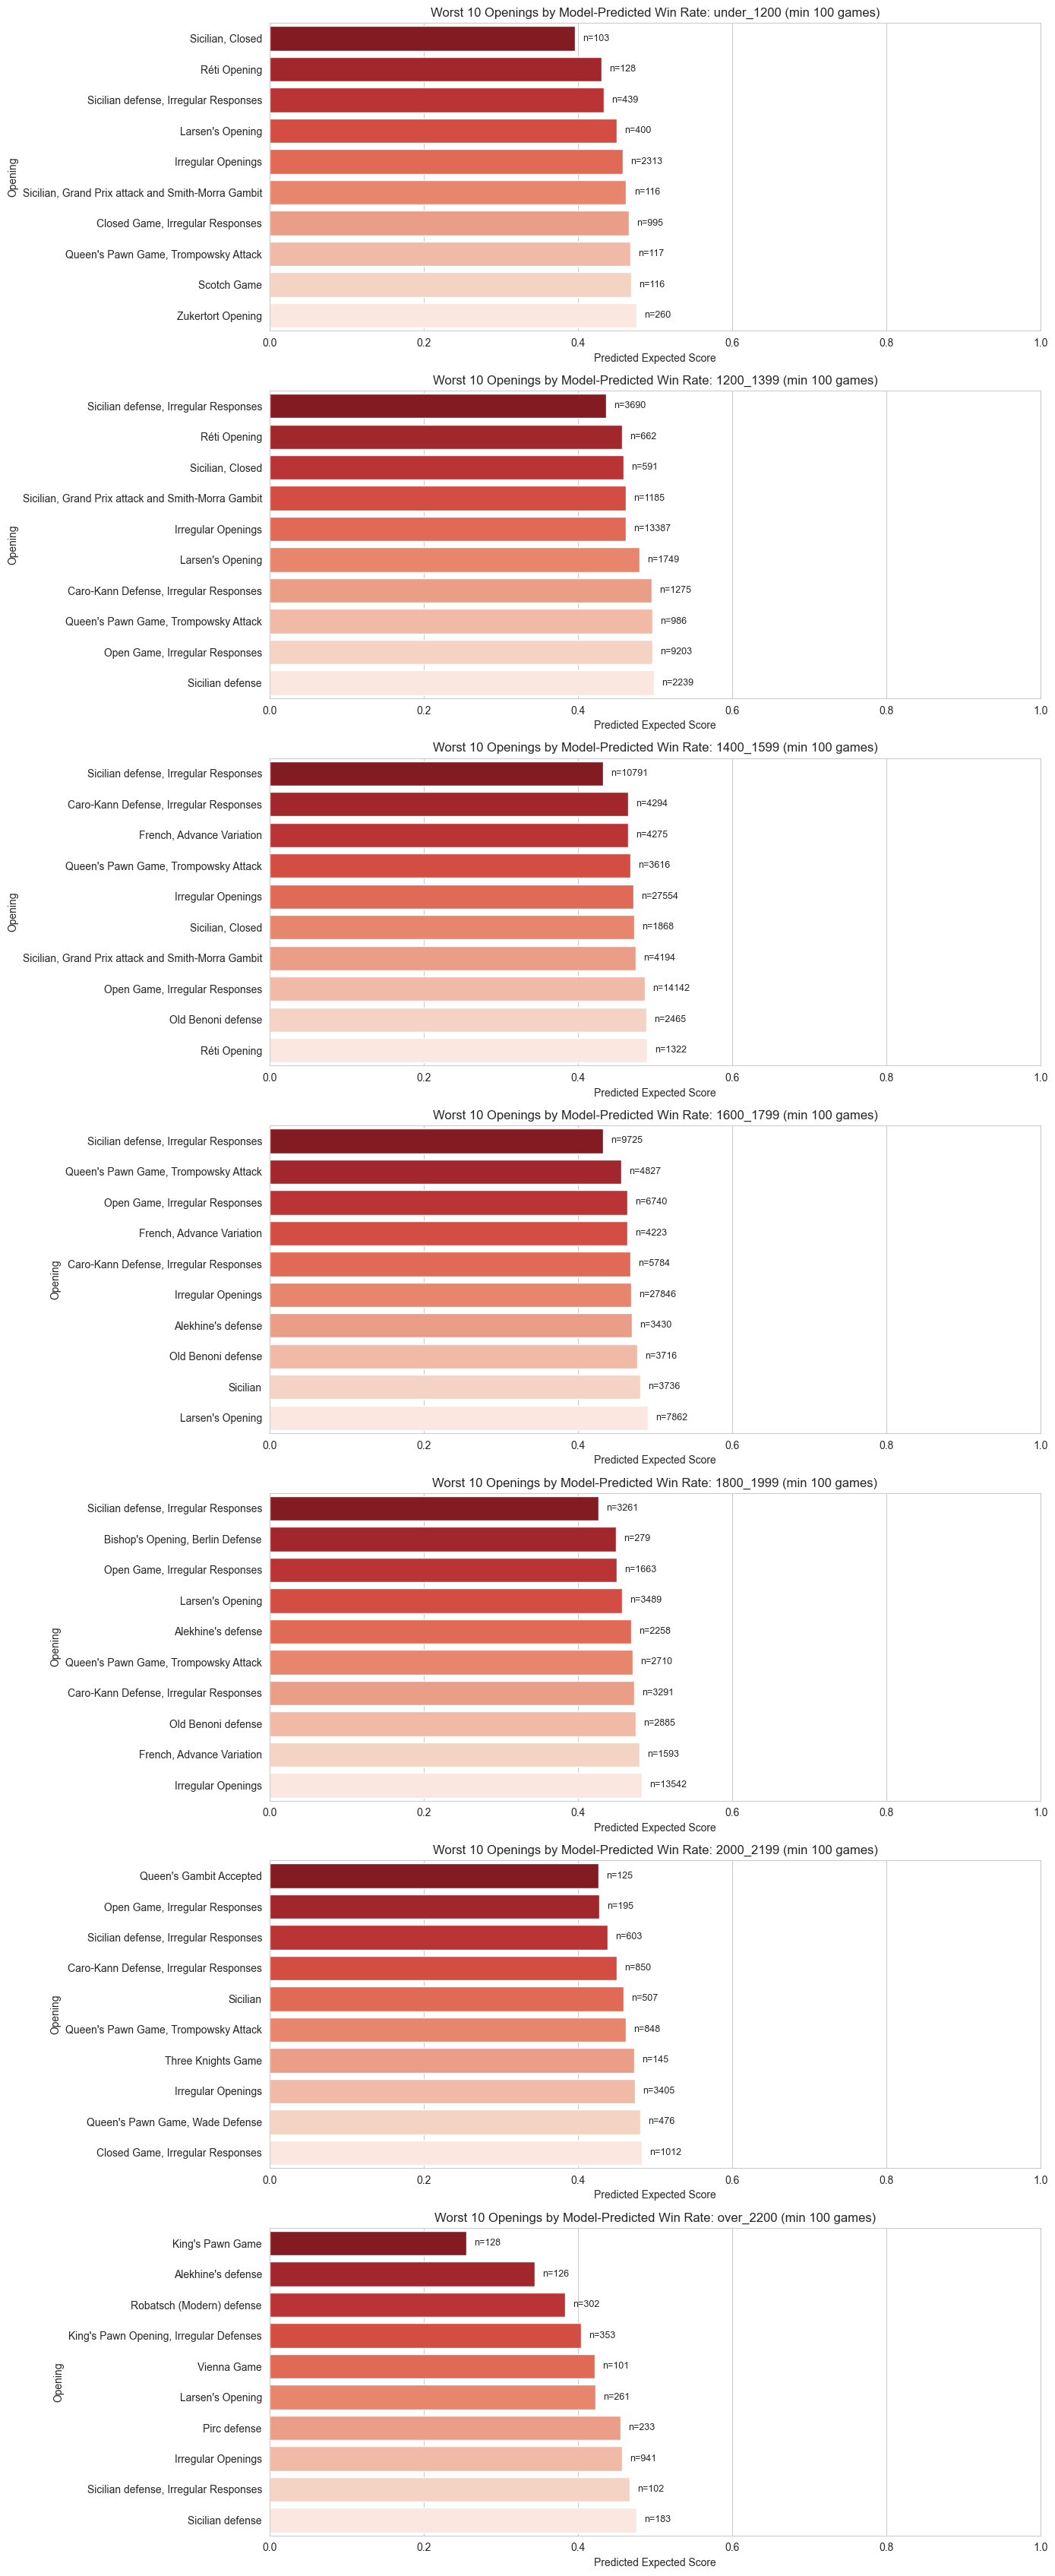

In [20]:
fig, axes = plt.subplots(len(bracket_order), 1, figsize=(14, 34))
sns.set_style("whitegrid")

for ax, bracket in zip(axes, bracket_order):
    plot_df = (
        worst10_per_bracket[worst10_per_bracket["Elo_Bracket"] == bracket]
        .sort_values("predicted_win_rate")
    )

    sns.barplot(
        data=plot_df,
        x="predicted_win_rate",
        y="FullName",
        ax=ax,
        palette="Reds_r"
    )

    ax.set_title(f"Worst 10 Openings by Model-Predicted Win Rate: {bracket} (min {MIN_GAMES} games)")
    ax.set_xlabel("Predicted Expected Score")
    ax.set_ylabel("Opening")
    ax.set_xlim(0, 1)

    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row["predicted_win_rate"] + 0.01, i, f'n={row["games"]}', va="center", fontsize=9)

plt.tight_layout()
plt.show()


### Worst Openings by Elo Bracket
The lowest-ranked openings in each Elo bracket are those with the weakest model-predicted expected score. These openings may be less effective for that rating group, or they may be associated with positions that are harder for players in that bracket to handle successfully.

These results are useful for identifying openings that may be risky or less practical for players at specific Elo levels.


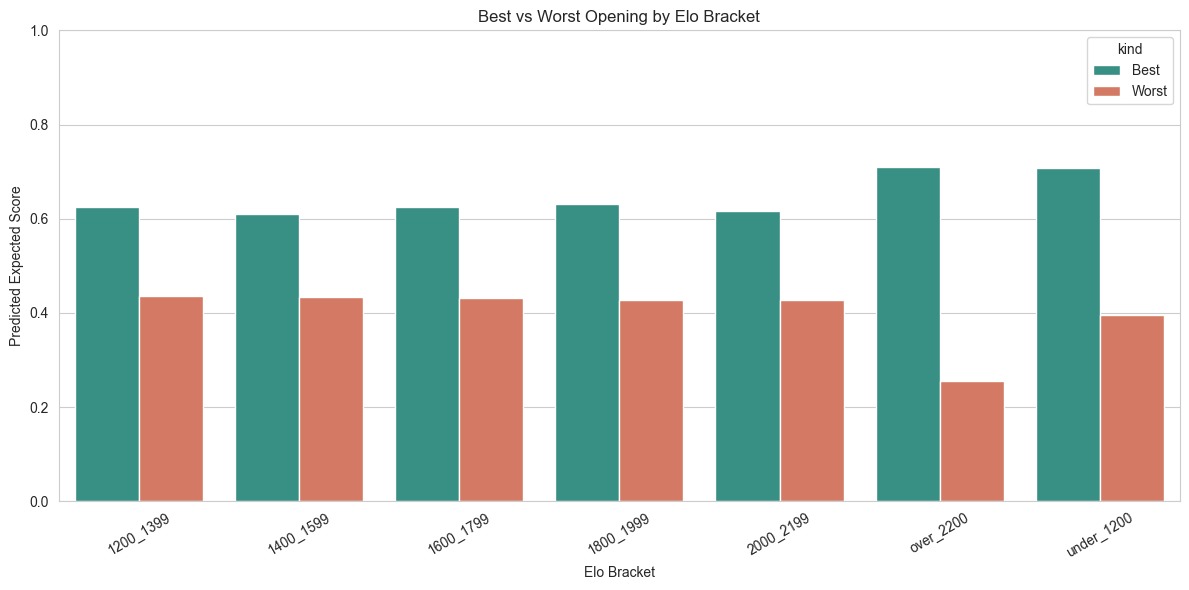

In [21]:
best1 = (
    top_openings.sort_values(
        ["Elo_Bracket", "predicted_win_rate", "games"],
        ascending=[True, False, False]
    )
    .groupby("Elo_Bracket", group_keys=False)
    .head(1)
    .assign(kind="Best")
)

worst1 = (
    top_openings.sort_values(
        ["Elo_Bracket", "predicted_win_rate", "games"],
        ascending=[True, True, False]
    )
    .groupby("Elo_Bracket", group_keys=False)
    .head(1)
    .assign(kind="Worst")
)

compare_df = pd.concat([best1, worst1], axis=0)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=compare_df,
    x="Elo_Bracket",
    y="predicted_win_rate",
    hue="kind",
    palette={"Best": "#2a9d8f", "Worst": "#e76f51"}
)
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.title("Best vs Worst Opening by Elo Bracket")
plt.ylabel("Predicted Expected Score")
plt.xlabel("Elo Bracket")
plt.tight_layout()
plt.show()


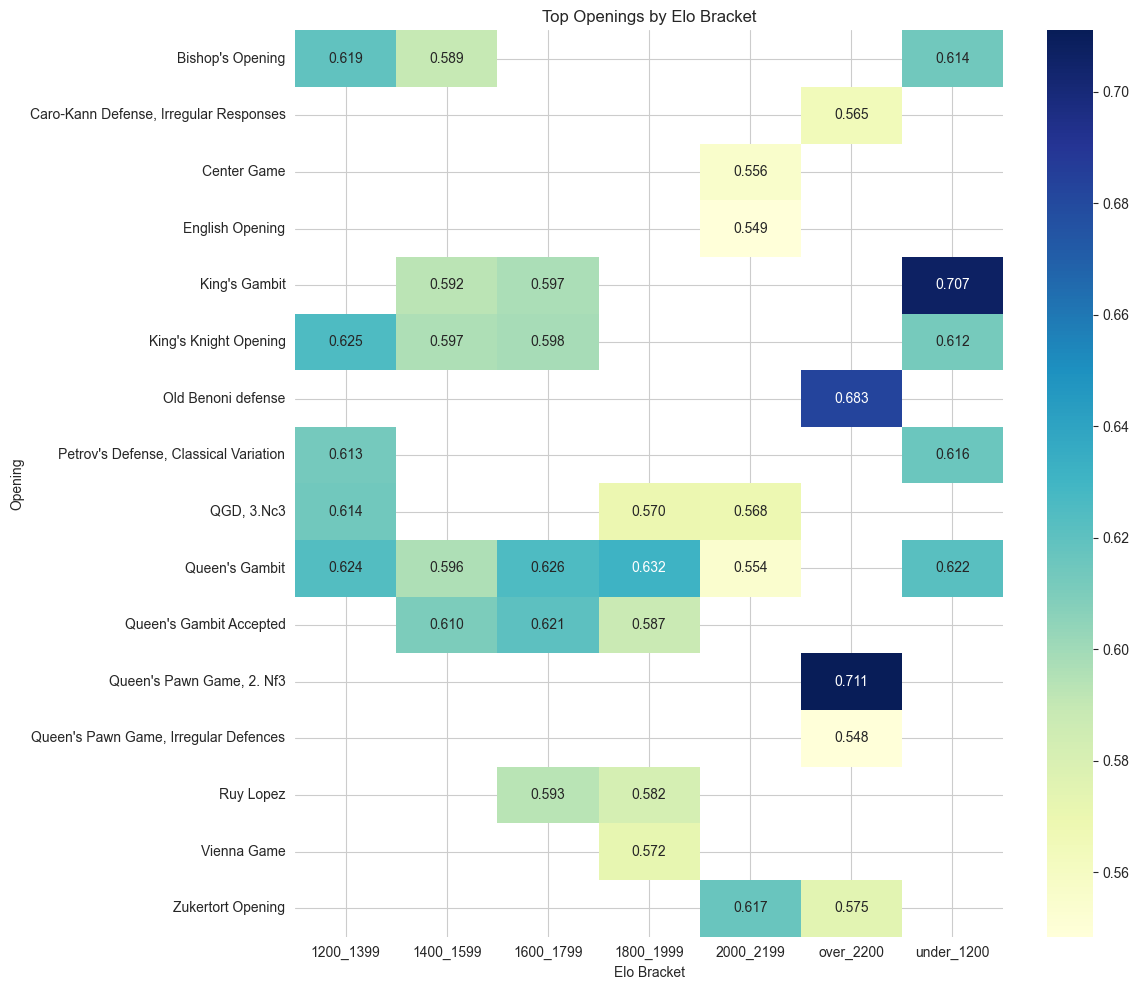

In [22]:
top_per_bracket = (
    top_openings.sort_values(
        ["Elo_Bracket", "predicted_win_rate", "games"],
        ascending=[True, False, False]
    )
    .groupby("Elo_Bracket", group_keys=False)
    .head(5)
)

heat_df = top_per_bracket.pivot_table(
    index="FullName",
    columns="Elo_Bracket",
    values="predicted_win_rate"
)

plt.figure(figsize=(12, 10))
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Top Openings by Elo Bracket")
plt.xlabel("Elo Bracket")
plt.ylabel("Opening")
plt.tight_layout()
plt.show()


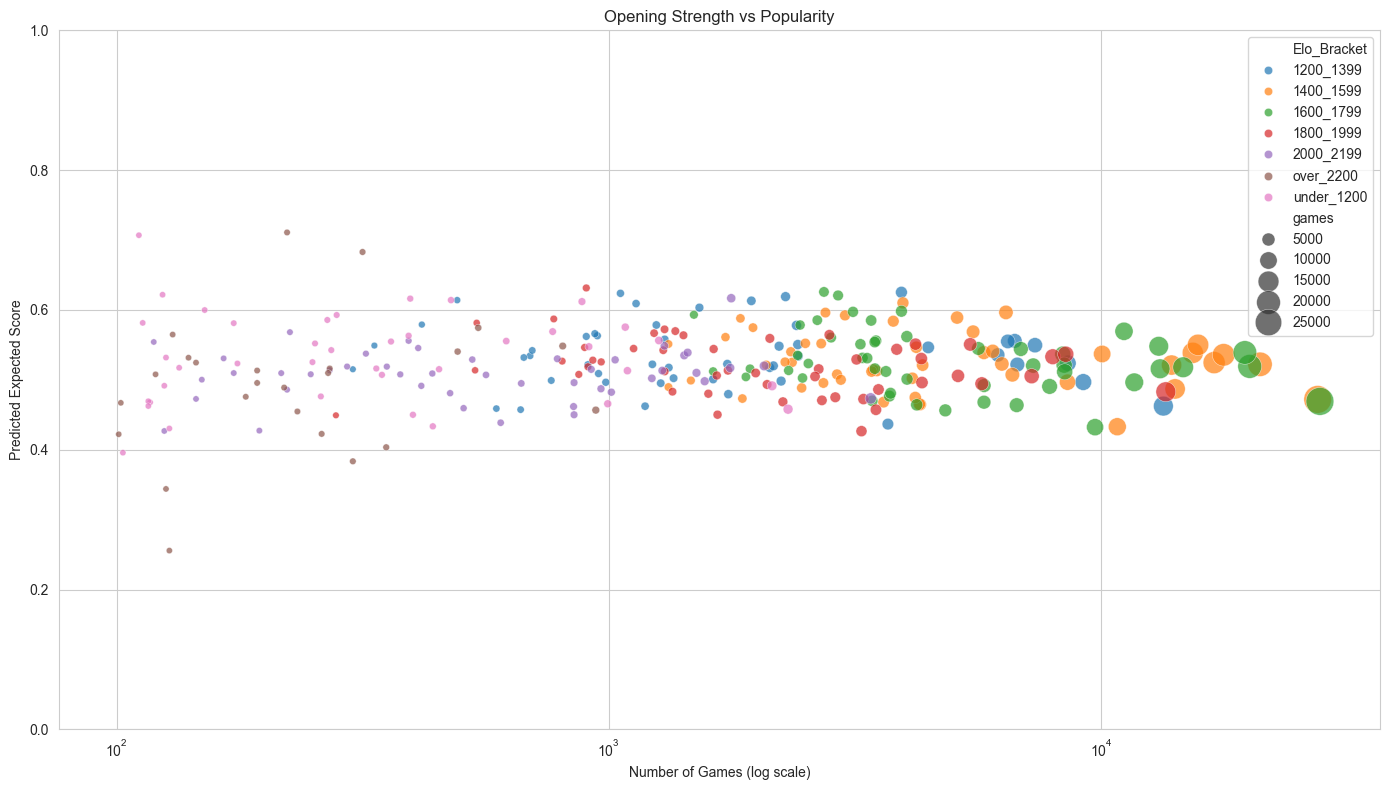

In [23]:
plot_df = top_openings.copy()

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=plot_df,
    x="games",
    y="predicted_win_rate",
    hue="Elo_Bracket",
    size="games",
    sizes=(20, 400),
    alpha=0.7
)
plt.xscale("log")
plt.ylim(0, 1)
plt.title("Opening Strength vs Popularity")
plt.xlabel("Number of Games (log scale)")
plt.ylabel("Predicted Expected Score")
plt.tight_layout()
plt.show()


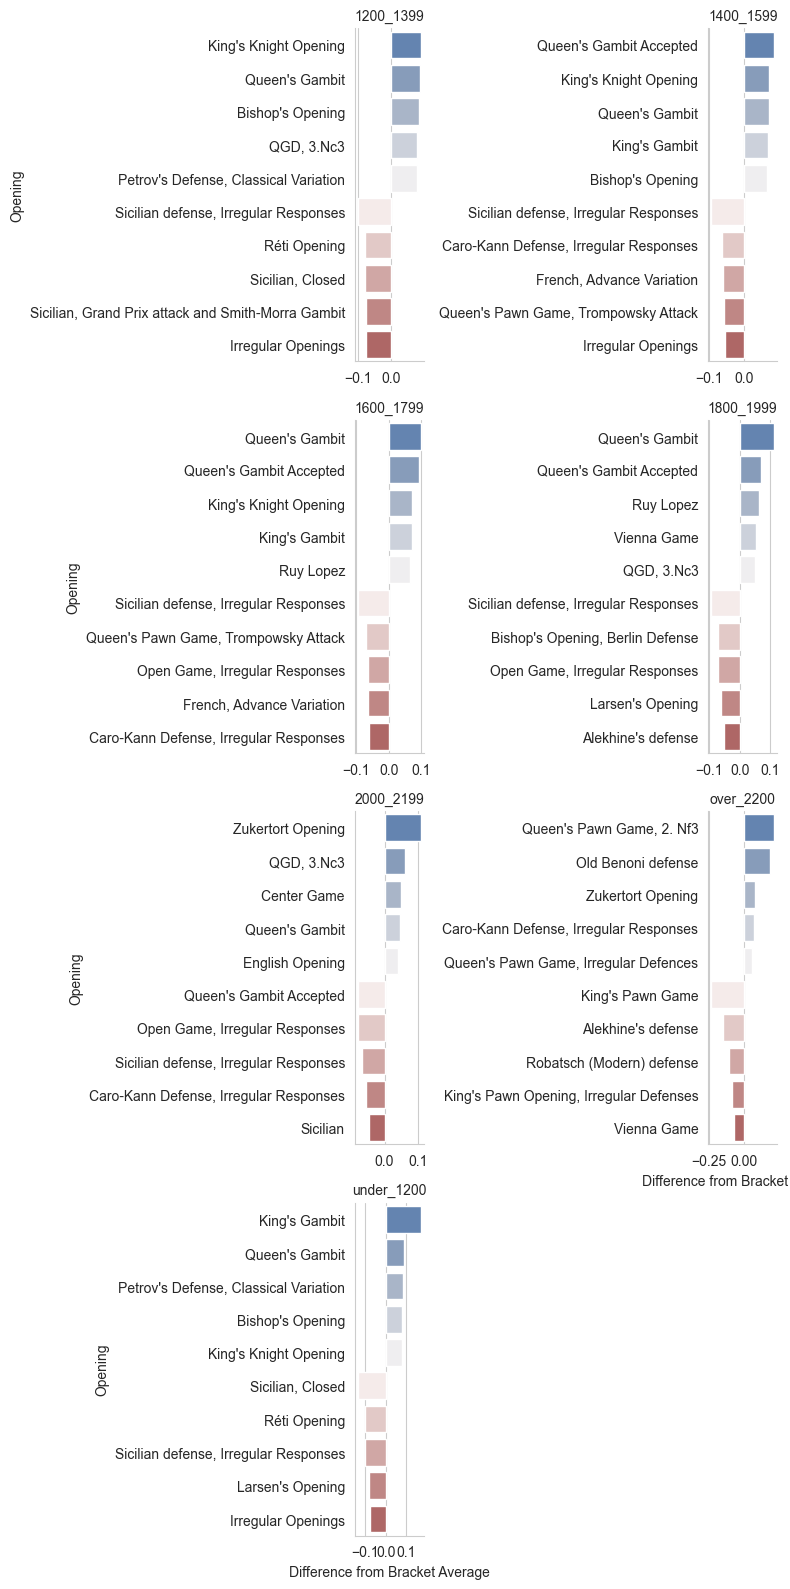

In [24]:
bracket_avg = (
    top_openings.groupby("Elo_Bracket")["predicted_win_rate"]
    .mean()
    .rename("bracket_avg")
    .reset_index()
)

delta_df = top_openings.merge(bracket_avg, on="Elo_Bracket")
delta_df["delta"] = delta_df["predicted_win_rate"] - delta_df["bracket_avg"]

top_delta = (
    delta_df.sort_values(["Elo_Bracket", "delta"], ascending=[True, False])
    .groupby("Elo_Bracket", group_keys=False)
    .head(5)
)

bottom_delta = (
    delta_df.sort_values(["Elo_Bracket", "delta"], ascending=[True, True])
    .groupby("Elo_Bracket", group_keys=False)
    .head(5)
)

fun_df = pd.concat([top_delta, bottom_delta], axis=0)

g = sns.FacetGrid(fun_df, col="Elo_Bracket", col_wrap=2, height=4, sharex=False, sharey=False)
g.map_dataframe(
    sns.barplot,
    x="delta",
    y="FullName",
    palette="vlag"
)
g.set_titles("{col_name}")
g.set_axis_labels("Difference from Bracket Average", "Opening")
plt.tight_layout()
plt.show()


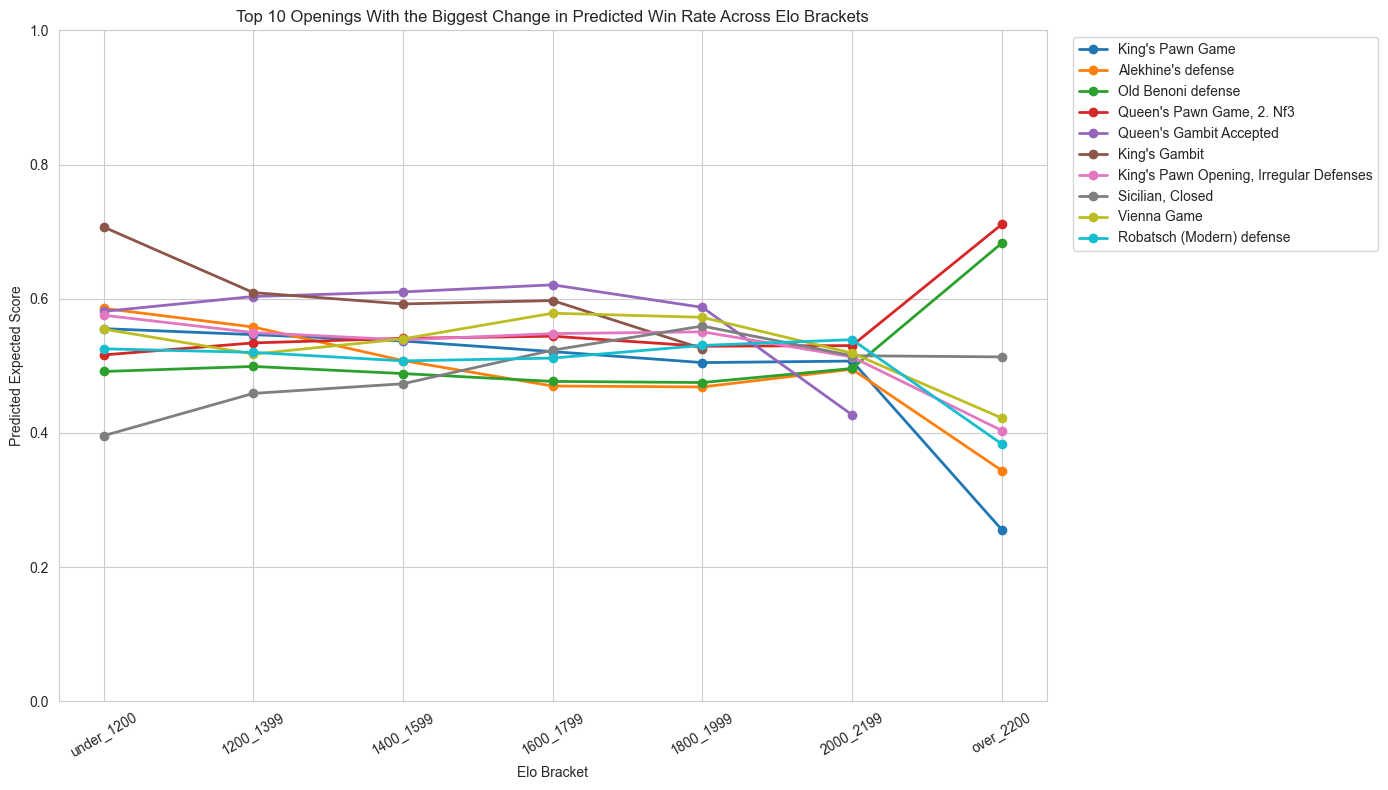

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

bracket_order = [
    "under_1200",
    "1200_1399",
    "1400_1599",
    "1600_1799",
    "1800_1999",
    "2000_2199",
    "over_2200"
]

MIN_GAMES_TOTAL = 500
MIN_BRACKETS_PRESENT = 4

variation_df = top_openings.copy()
variation_df["Elo_Bracket"] = pd.Categorical(
    variation_df["Elo_Bracket"],
    categories=bracket_order,
    ordered=True
)

opening_variation = (
    variation_df.groupby("FullName")
    .agg(
        total_games=("games", "sum"),
        n_brackets=("Elo_Bracket", "nunique"),
        min_score=("predicted_win_rate", "min"),
        max_score=("predicted_win_rate", "max"),
        mean_score=("predicted_win_rate", "mean"),
        std_score=("predicted_win_rate", "std"),
    )
    .reset_index()
)

opening_variation["score_range"] = opening_variation["max_score"] - opening_variation["min_score"]

selected = (
    opening_variation[
        (opening_variation["total_games"] >= MIN_GAMES_TOTAL) &
        (opening_variation["n_brackets"] >= MIN_BRACKETS_PRESENT)
    ]
    .sort_values(["score_range", "total_games"], ascending=[False, False])
    .head(10)["FullName"]
)

plot_df = variation_df[variation_df["FullName"].isin(selected)].copy()

plt.figure(figsize=(14, 8))
for opening in selected:
    sub = plot_df[plot_df["FullName"] == opening].sort_values("Elo_Bracket")
    plt.plot(
        sub["Elo_Bracket"],
        sub["predicted_win_rate"],
        marker="o",
        linewidth=2,
        label=opening
    )

plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.title("Top 10 Openings With the Biggest Change in Predicted Win Rate Across Elo Brackets")
plt.xlabel("Elo Bracket")
plt.ylabel("Predicted Expected Score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

bracket_order = [
    "under_1200",
    "1200_1399",
    "1400_1599",
    "1600_1799",
    "1800_1999",
    "2000_2199",
    "over_2200"
]

MIN_GAMES_TOTAL = 500
MIN_BRACKETS_PRESENT = 4

trend_df = top_openings.copy()
trend_df["Elo_Bracket"] = pd.Categorical(
    trend_df["Elo_Bracket"],
    categories=bracket_order,
    ordered=True
)

opening_trend = (
    trend_df.groupby("FullName")
    .agg(
        total_games=("games", "sum"),
        n_brackets=("Elo_Bracket", "nunique"),
    )
    .reset_index()
)

first_last = (
    trend_df[trend_df["Elo_Bracket"].isin([bracket_order[0], bracket_order[-1]])]
    .pivot_table(
        index="FullName",
        columns="Elo_Bracket",
        values="predicted_win_rate"
    )
    .reset_index()
)

opening_trend = opening_trend.merge(first_last, on="FullName", how="left")
opening_trend = opening_trend.rename(columns={
    bracket_order[0]: "low_elo_score",
    bracket_order[-1]: "high_elo_score"
})

opening_trend["delta"] = opening_trend["high_elo_score"] - opening_trend["low_elo_score"]

eligible = opening_trend[
    (opening_trend["total_games"] >= MIN_GAMES_TOTAL) &
    (opening_trend["n_brackets"] >= MIN_BRACKETS_PRESENT) &
    opening_trend["low_elo_score"].notna() &
    opening_trend["high_elo_score"].notna()
].copy()

top_increase = eligible.sort_values(["delta", "total_games"], ascending=[False, False]).head(10)
top_decrease = eligible.sort_values(["delta", "total_games"], ascending=[True, False]).head(10)


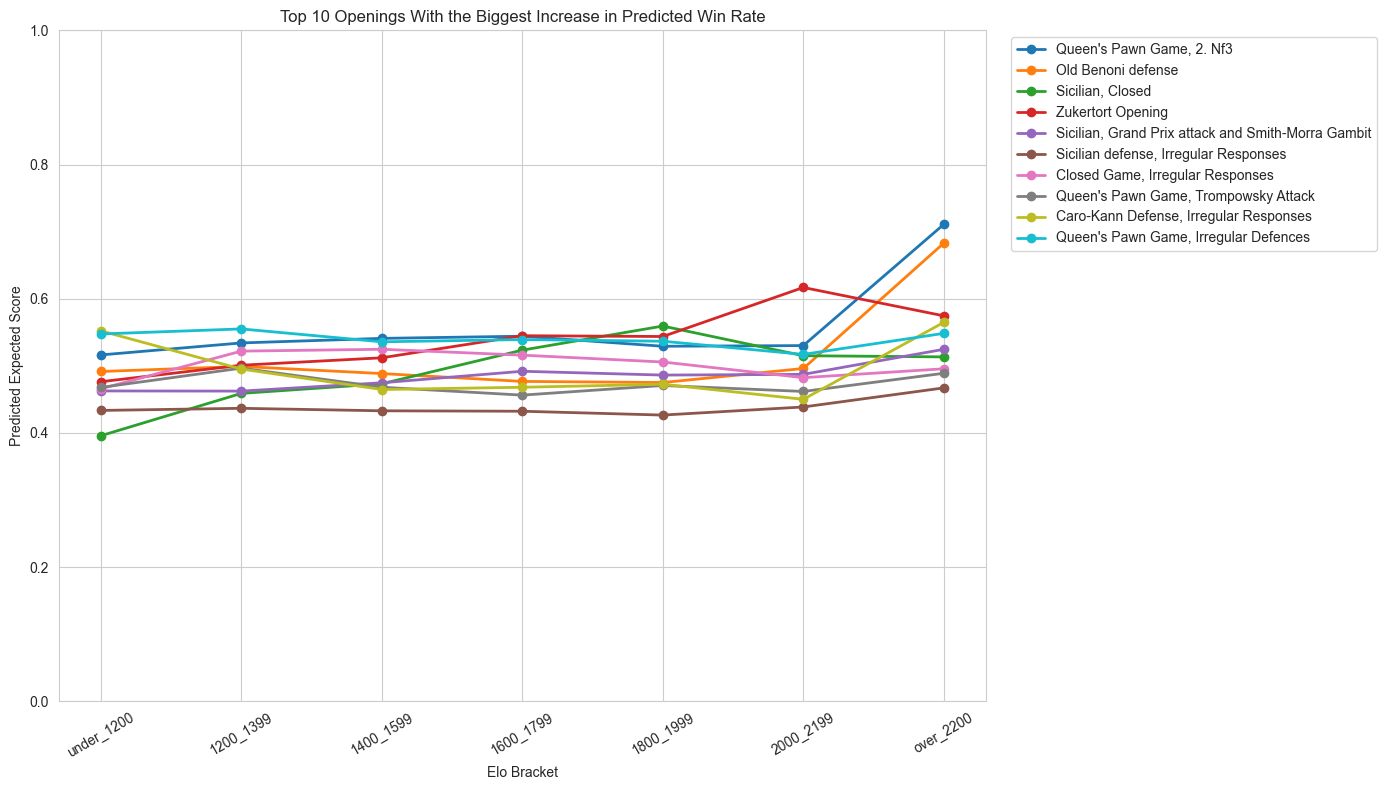

In [27]:
increase_names = top_increase["FullName"].tolist()
plot_inc = trend_df[trend_df["FullName"].isin(increase_names)].copy()

plt.figure(figsize=(14, 8))
for opening in increase_names:
    sub = plot_inc[plot_inc["FullName"] == opening].sort_values("Elo_Bracket")
    plt.plot(sub["Elo_Bracket"], sub["predicted_win_rate"], marker="o", linewidth=2, label=opening)

plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.title("Top 10 Openings With the Biggest Increase in Predicted Win Rate")
plt.xlabel("Elo Bracket")
plt.ylabel("Predicted Expected Score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


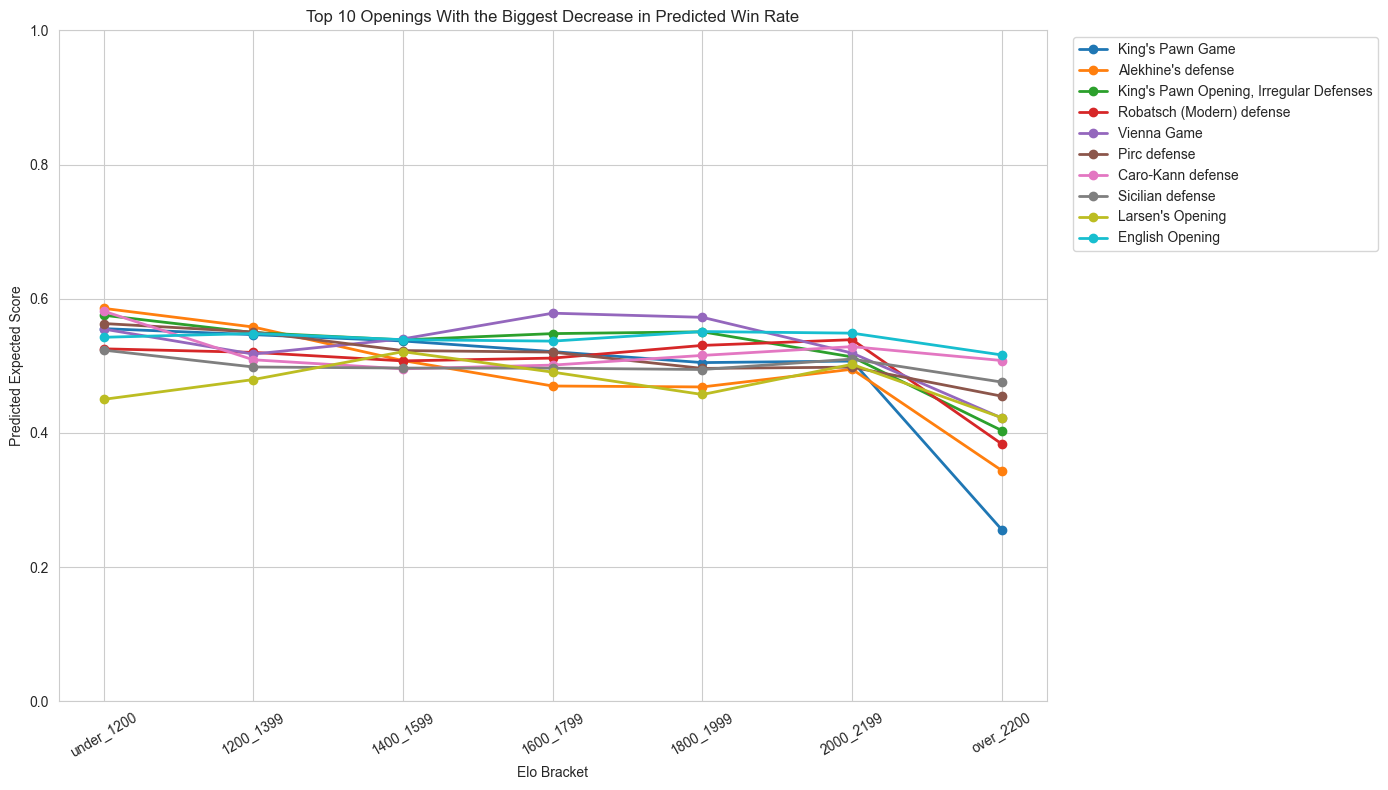

In [28]:
decrease_names = top_decrease["FullName"].tolist()
plot_dec = trend_df[trend_df["FullName"].isin(decrease_names)].copy()

plt.figure(figsize=(14, 8))
for opening in decrease_names:
    sub = plot_dec[plot_dec["FullName"] == opening].sort_values("Elo_Bracket")
    plt.plot(sub["Elo_Bracket"], sub["predicted_win_rate"], marker="o", linewidth=2, label=opening)

plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.title("Top 10 Openings With the Biggest Decrease in Predicted Win Rate")
plt.xlabel("Elo Bracket")
plt.ylabel("Predicted Expected Score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Additional Report Plots
These plots are designed to strengthen the report discussion around **which openings are most suitable for each Elo range**. They focus on four angles: relative advantage within a bracket, how opening rankings change with strength, how reliable the top recommendations are, and what broad opening families work best for different rating groups.


In [31]:
# Shared preparation for the additional report plots
all_scored_df = pd.concat([
    train_df[["Elo_Bracket", "FullName", "ExpectedScore"]].assign(predicted_score=train_pred),
    val_df[["Elo_Bracket", "FullName", "ExpectedScore"]].assign(predicted_score=val_pred),
    test_df[["Elo_Bracket", "FullName", "ExpectedScore"]].assign(predicted_score=test_pred),
], axis=0)

all_scored_df["Elo_Bracket"] = pd.Categorical(
    all_scored_df["Elo_Bracket"],
    categories=bracket_order,
    ordered=True,
)

# Use the most common family label per opening name.
opening_family_lookup = (
    df[["FullName", "Opening_Family"]]
    .dropna()
    .groupby("FullName")["Opening_Family"]
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0])
)


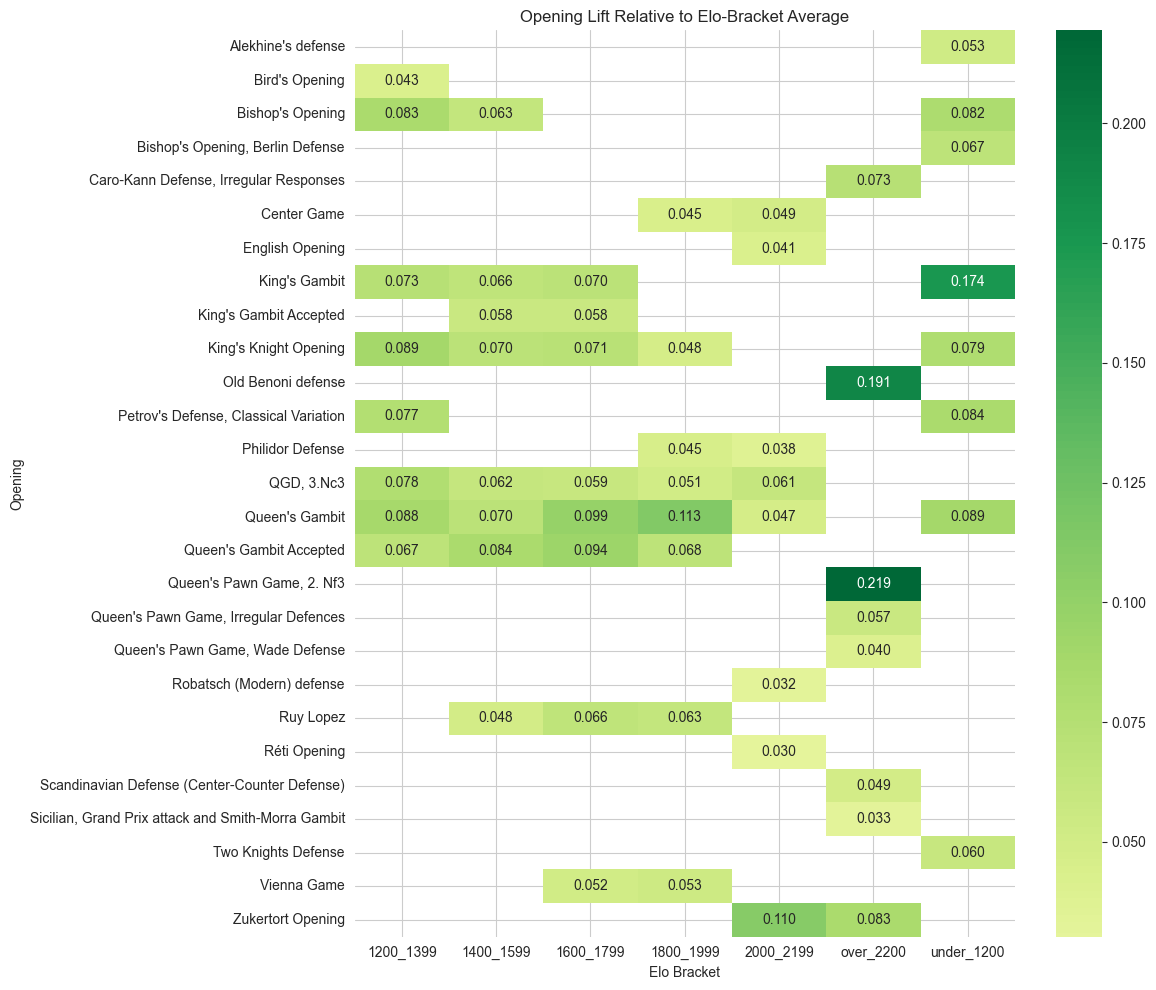

In [32]:
# Plot 1: heatmap of opening lift relative to the average score of each Elo bracket
lift_top = (
    delta_df.sort_values(["Elo_Bracket", "delta"], ascending=[True, False])
    .groupby("Elo_Bracket", group_keys=False)
    .head(8)
)

lift_heat = lift_top.pivot_table(
    index="FullName",
    columns="Elo_Bracket",
    values="delta",
)

plt.figure(figsize=(12, 10))
sns.heatmap(lift_heat, annot=True, fmt=".3f", cmap="RdYlGn", center=0)
plt.title("Opening Lift Relative to Elo-Bracket Average")
plt.xlabel("Elo Bracket")
plt.ylabel("Opening")
plt.tight_layout()
plt.show()


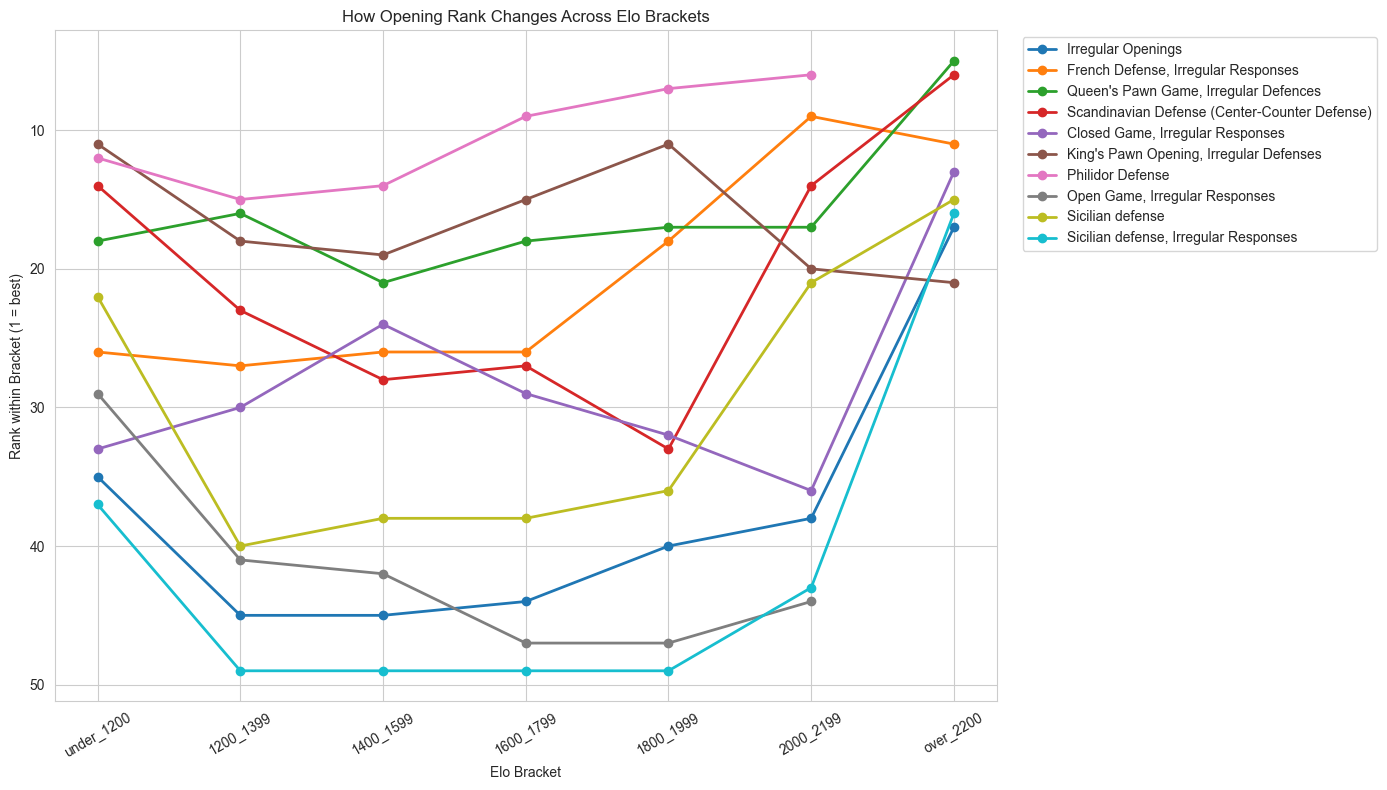

In [33]:
# Plot 2: bump chart showing how opening rank changes across Elo brackets
rank_df = top_openings.copy()
rank_df["Elo_Bracket"] = pd.Categorical(
    rank_df["Elo_Bracket"],
    categories=bracket_order,
    ordered=True,
)

rank_df["rank"] = (
    rank_df.groupby("Elo_Bracket")["predicted_win_rate"]
    .rank(method="dense", ascending=False)
)

selected_openings = (
    rank_df.groupby("FullName")
    .agg(total_games=("games", "sum"), n_brackets=("Elo_Bracket", "nunique"))
    .query("total_games >= 1500 and n_brackets >= 5")
    .sort_values("total_games", ascending=False)
    .head(10)
    .index
)

plot_df = rank_df[rank_df["FullName"].isin(selected_openings)].copy()

plt.figure(figsize=(14, 8))
for opening in selected_openings:
    sub = plot_df[plot_df["FullName"] == opening].sort_values("Elo_Bracket")
    plt.plot(sub["Elo_Bracket"], sub["rank"], marker="o", linewidth=2, label=opening)

plt.gca().invert_yaxis()
plt.xticks(rotation=30)
plt.title("How Opening Rank Changes Across Elo Brackets")
plt.xlabel("Elo Bracket")
plt.ylabel("Rank within Bracket (1 = best)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


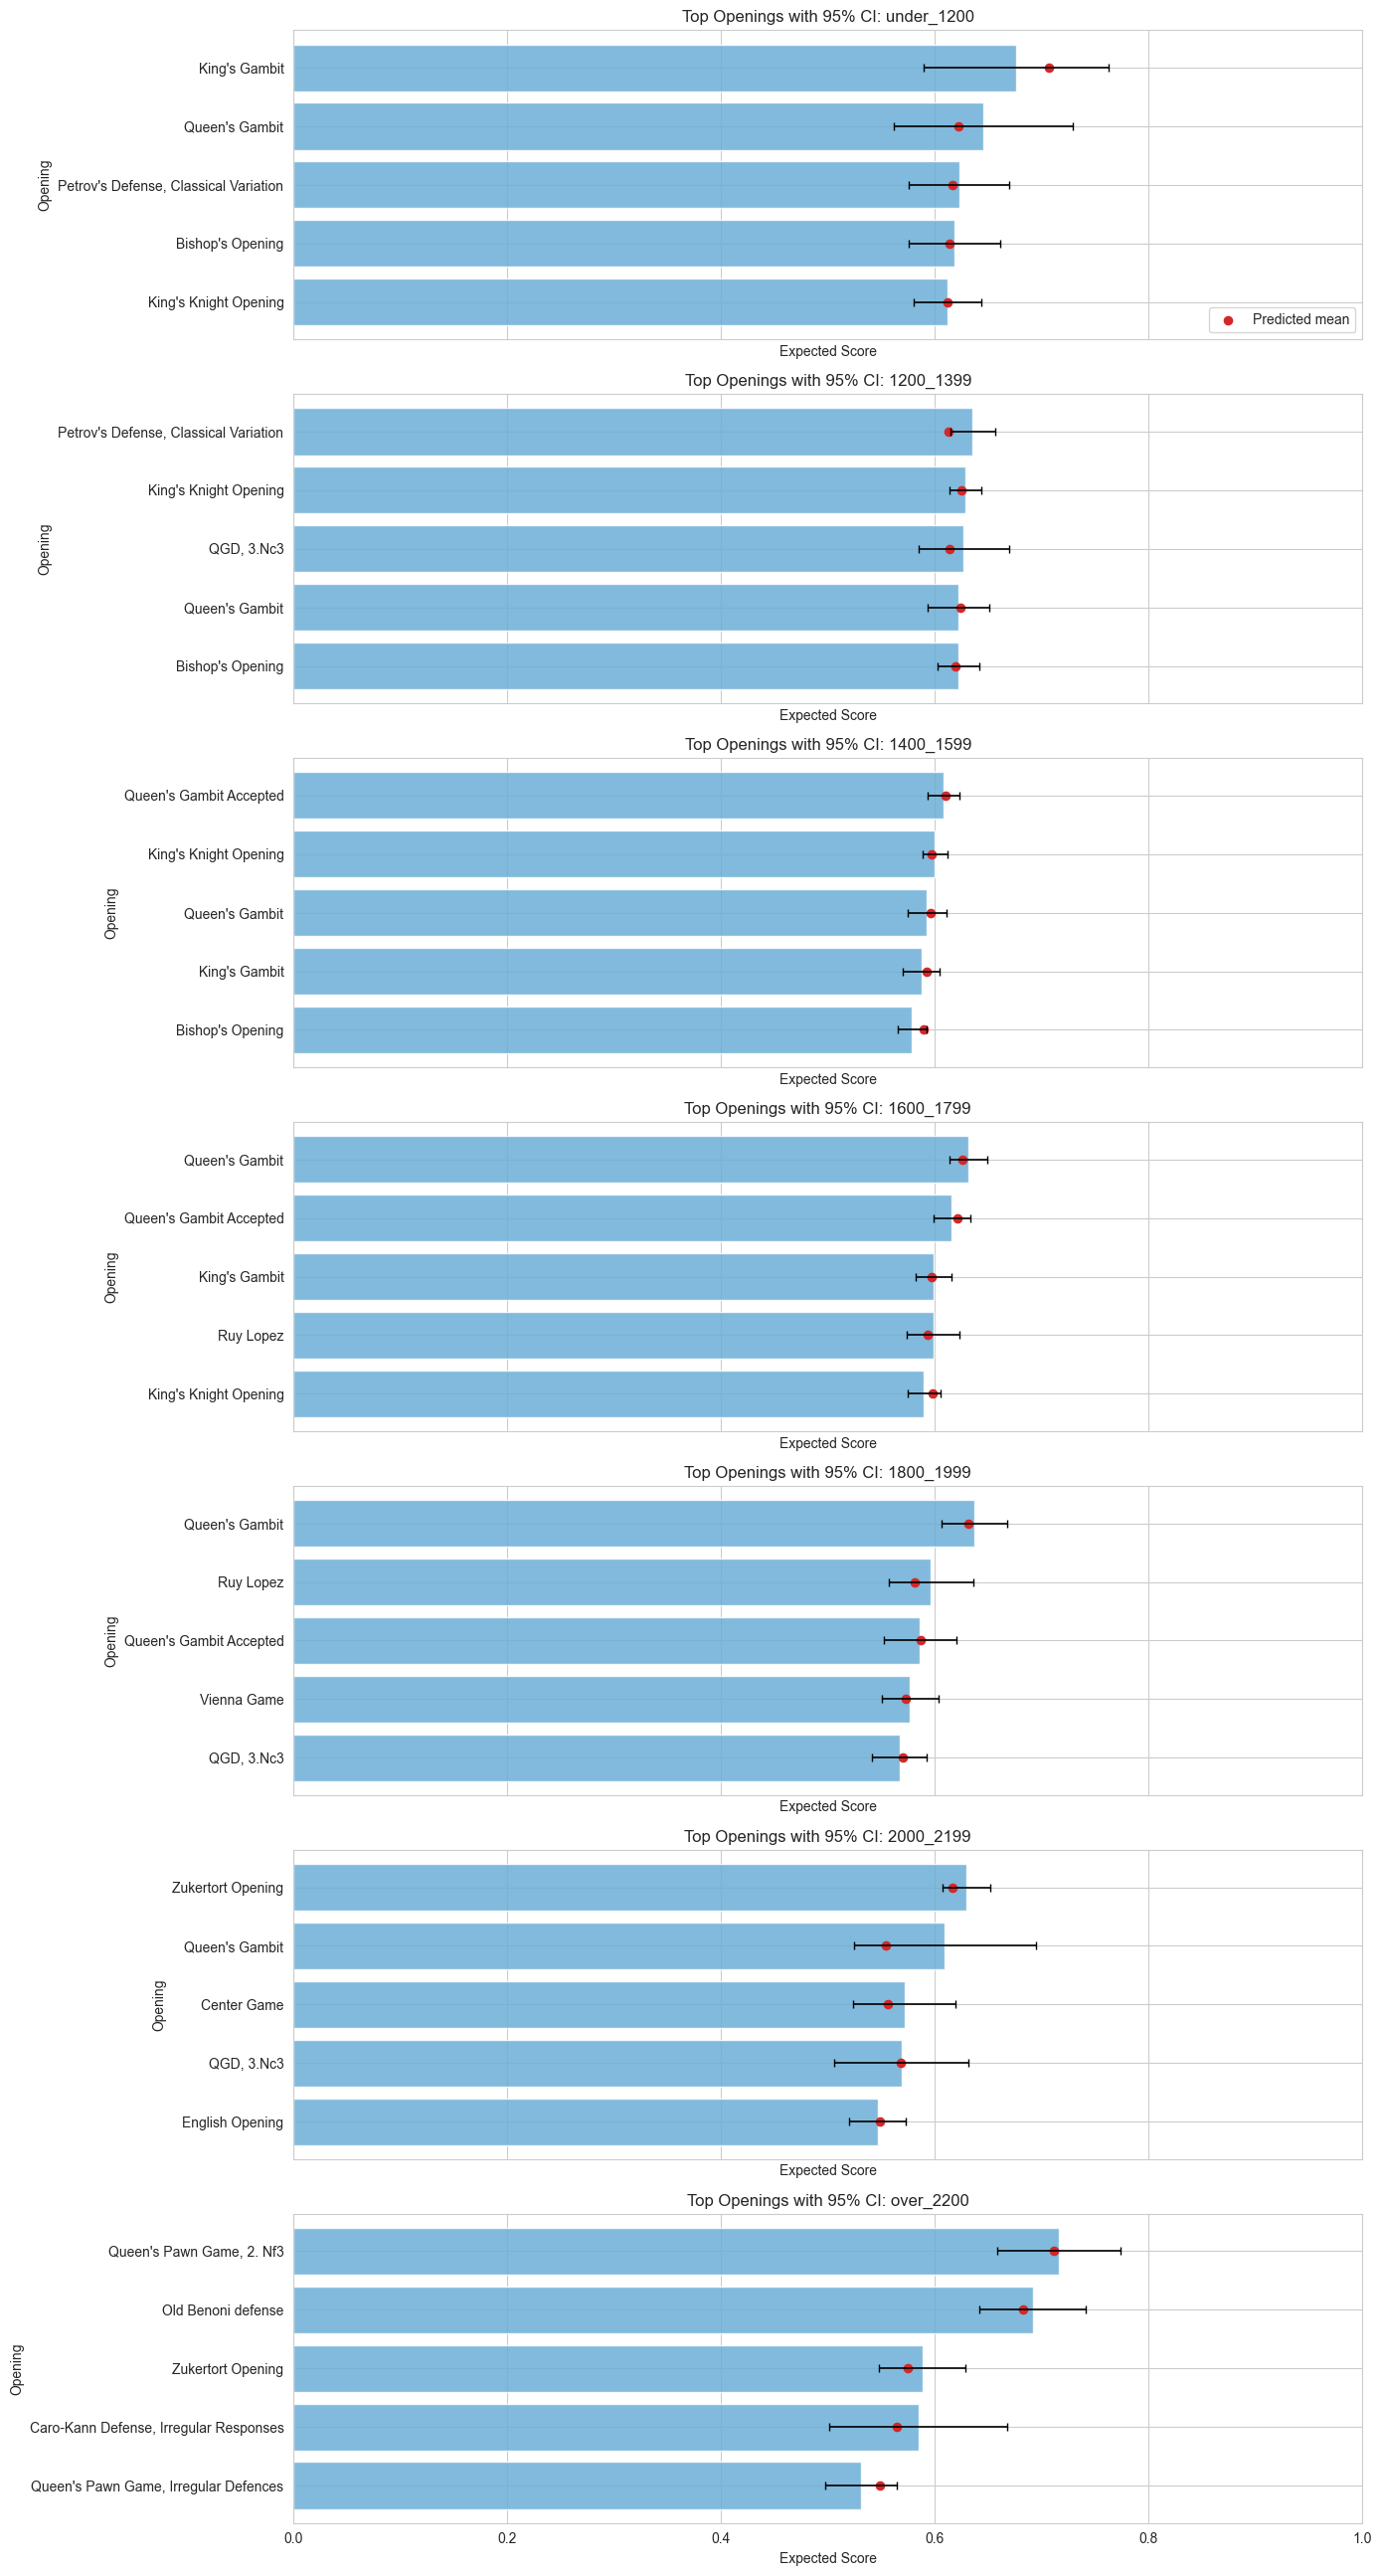

In [34]:
# Plot 3: confidence intervals for the top openings in each Elo bracket using observed outcomes
ci_base = (
    all_scored_df.groupby(["Elo_Bracket", "FullName"], observed=True)
    .agg(
        games=("ExpectedScore", "size"),
        actual_mean=("ExpectedScore", "mean"),
        predicted_mean=("predicted_score", "mean"),
        actual_std=("ExpectedScore", "std"),
    )
    .reset_index()
)

ci_base = ci_base[ci_base["games"] >= MIN_GAMES].copy()
ci_base["se"] = ci_base["actual_std"].fillna(0) / np.sqrt(ci_base["games"])
ci_base["ci95"] = 1.96 * ci_base["se"]

ci_top = (
    ci_base.sort_values(["Elo_Bracket", "predicted_mean", "games"], ascending=[True, False, False])
    .groupby("Elo_Bracket", group_keys=False)
    .head(5)
)

fig, axes = plt.subplots(len(bracket_order), 1, figsize=(14, 26), sharex=True)

for ax, bracket in zip(axes, bracket_order):
    sub = ci_top[ci_top["Elo_Bracket"] == bracket].sort_values("actual_mean")
    if sub.empty:
        ax.set_visible(False)
        continue

    ax.barh(sub["FullName"], sub["actual_mean"], color="#6baed6", alpha=0.85)
    ax.errorbar(
        x=sub["actual_mean"],
        y=sub["FullName"],
        xerr=sub["ci95"],
        fmt="none",
        ecolor="black",
        capsize=3,
        linewidth=1.2,
    )
    ax.scatter(sub["predicted_mean"], sub["FullName"], color="#d62728", s=35, label="Predicted mean")
    ax.set_title(f"Top Openings with 95% CI: {bracket}")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Expected Score")
    ax.set_ylabel("Opening")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(handles, labels, loc="lower right")

plt.tight_layout()
plt.show()


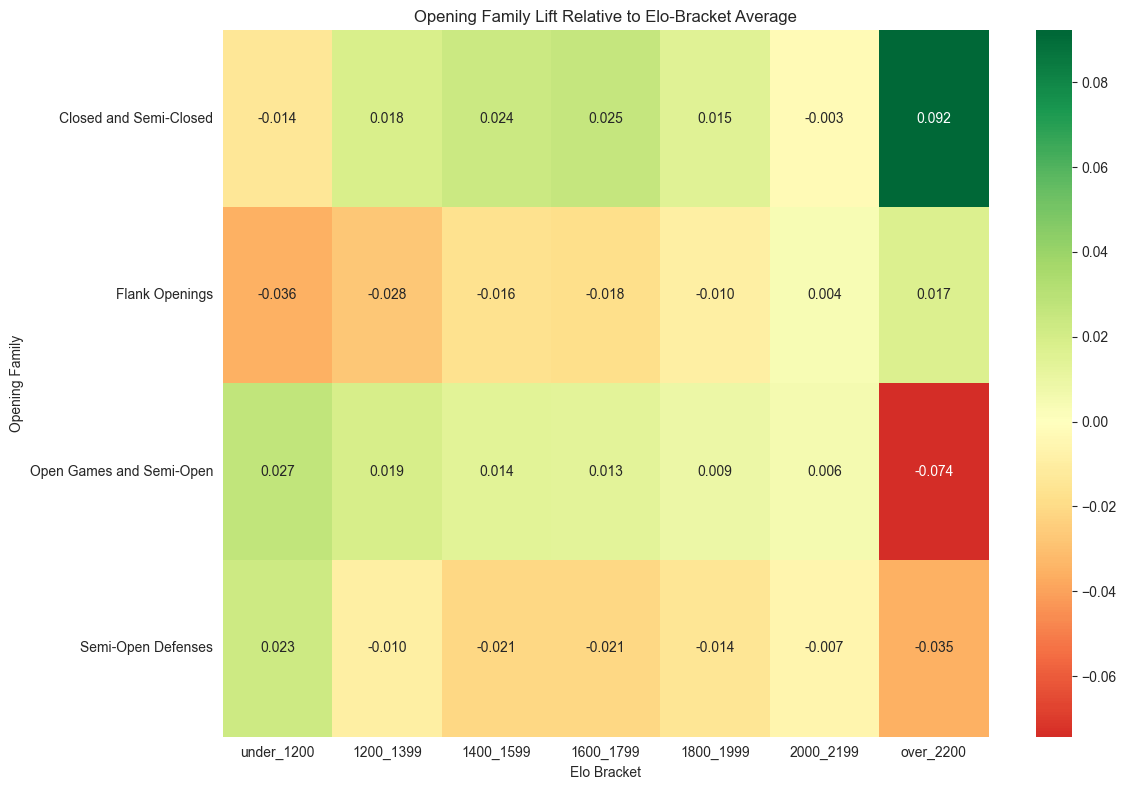

In [35]:
# Plot 4: opening-family heatmap for a broader strategic summary
family_df = all_scored_df.copy()
family_df["Opening_Family"] = family_df["FullName"].map(opening_family_lookup)
family_df = family_df.dropna(subset=["Opening_Family"]).copy()

family_summary = (
    family_df.groupby(["Opening_Family", "Elo_Bracket"], observed=True)
    .agg(
        games=("ExpectedScore", "size"),
        predicted_mean=("predicted_score", "mean"),
    )
    .reset_index()
)

family_summary = family_summary[family_summary["games"] >= 200].copy()
family_avg = family_summary.groupby("Elo_Bracket")["predicted_mean"].transform("mean")
family_summary["lift_vs_bracket"] = family_summary["predicted_mean"] - family_avg

top_families = (
    family_summary.groupby("Opening_Family")["games"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)

family_heat = (
    family_summary[family_summary["Opening_Family"].isin(top_families)]
    .pivot_table(index="Opening_Family", columns="Elo_Bracket", values="lift_vs_bracket")
)

plt.figure(figsize=(12, 8))
sns.heatmap(family_heat, annot=True, fmt=".3f", cmap="RdYlGn", center=0)
plt.title("Opening Family Lift Relative to Elo-Bracket Average")
plt.xlabel("Elo Bracket")
plt.ylabel("Opening Family")
plt.tight_layout()
plt.show()
